<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>ReneWind: Wind Turbine Failure Prediction Using Neural Networks</font></center>
<center><font size=6>UT Austin AIML Program — Neural Networks Project</font></center>
<center><font size=6><b>Prepared by: Usiere Uko</b></font></center>

<div align="center">

<img src="https://images.pexels.com/photos/12388714/pexels-photo-12388714.jpeg?auto=compress&cs=tinysrgb&w=1200"
width="600"/>

</div>

## Executive Summary

This project develops neural network classification models to predict wind turbine generator failures using operational sensor data from ReneWind, a renewable energy company. The analysis aims to support predictive maintenance strategies, reduce operational downtime, and minimize maintenance costs through early failure detection.

---

## Problem Statement

ReneWind seeks to improve wind turbine maintenance operations by identifying potential generator failures before breakdowns occur. Unexpected failures can increase repair costs, replacement costs, and operational downtime.

The objective of this project is to build and evaluate neural network classification models that can accurately predict turbine generator failures using sensor-based operational data.

---

## Objectives

- Analyze wind turbine operational and sensor data
- Build neural network classification models for failure prediction
- Reduce false negatives by identifying failures early
- Support predictive maintenance and cost optimization strategies

---

## Data Description

The dataset contains transformed operational and sensor-related data collected from wind turbine generators. The project uses:

- `Train.csv` for model training and tuning
- `Test.csv` for evaluating final model performance

The dataset includes 40 predictor variables and 1 target variable representing generator failure status.

---

## Data Dictionary

The dataset includes variables related to:

- Environmental operating conditions
- Turbine and generator sensor measurements
- Equipment performance indicators
- Wind turbine failure classifications

# **Installing and Importing the necessary libraries**

In [2]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 827.6 kB/s eta 0:00:00


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [3]:
# Library for data manipulation and analysis.
import pandas as pd
# Fundamental package for scientific computing.
import numpy as np
#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
#Imports tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer
#Imports the Matplotlib library for creating visualizations.
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
#Imports metrics from
from sklearn import metrics

#Imports the tensorflow,keras and layers.
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization
from tensorflow.keras import backend

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# **Loading the Data**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
rdf = pd.read_csv("/content/drive/MyDrive/Train.csv")
df_test = pd.read_csv("/content/drive/MyDrive/Test.csv")

# **Data Overview**

The initial steps to get an overview of any dataset is to:
- observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- get information about the number of rows and columns in the dataset
- find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- check the statistical summary of the dataset to get an overview of the numerical columns of the data

## Checking the shape of the dataset

In [6]:
# Checking the number of rows and columns in the training data
rdf.shape

(20000, 41)



*   The training data set has 20000 rows and 41 columns

In [7]:
# Checking the number of rows and columns in the test data
df_test.shape

(5000, 41)

*   The test data set has 5000 rows and 41 columns

In [8]:
# let's create a copy of the training data
data = rdf.copy()

In [9]:
# let's create a copy of the testing  data
data_test = df_test.copy()

## Displaying the first few rows of the dataset

In [10]:
# let's view the first 5 rows of the data
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [11]:
#viewing first 5 rows of the test data
data_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


## Checking the data types of the columns in the dataset

In [12]:
# let's check the data types of the columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22



*   All colums in the training set have numerical data





Converting Target column to float

In [13]:
data['Target'] = data['Target'].astype(float)

Now checking for test data

In [14]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

*   All colums in the test set have numerical data

Converting Target to float

In [15]:
data_test['Target'] = data_test['Target'].astype(float)

## Checking for duplicate values

In [16]:
# let's check for duplicate values in the data
data.duplicated().sum()

np.int64(0)



*   There are no duplicate values in the data

## Checking for missing values

In [17]:
# let's check for missing values in the data
data.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


- There are no missing values in columns V3 to V40, while columns V1 and V2 each contain 18 missing values in the training dataset.

In [18]:
# let's check for missing values in the test data
data_test.isnull().sum() #

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


- There are no missing values in columns V3 to V40, while columns V1 and V2 contain 5 and 6 missing values respectively in the test dataset.

## Statistical summary of the dataset

In [19]:
# let's view the statistical summary of the numerical columns in the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


*   The columns have values ranging from about  -20 to 24
*   Most means are close to zero suggesting the data is centered
*   The standard deviations generally range between 1 and 4

# **Exploratory Data Analysis**

## Univariate analysis

In [20]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Variables V1 to V40

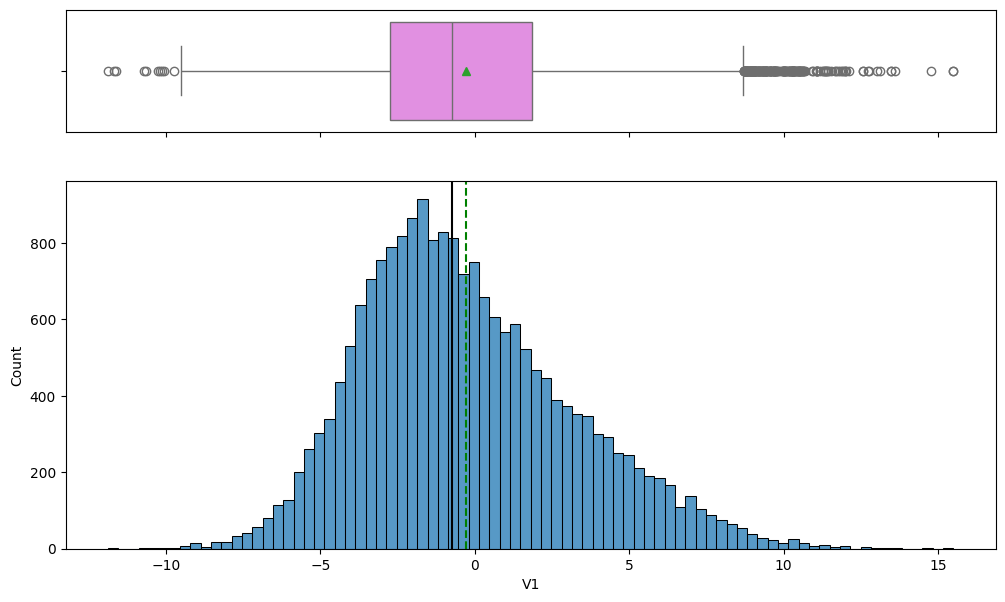

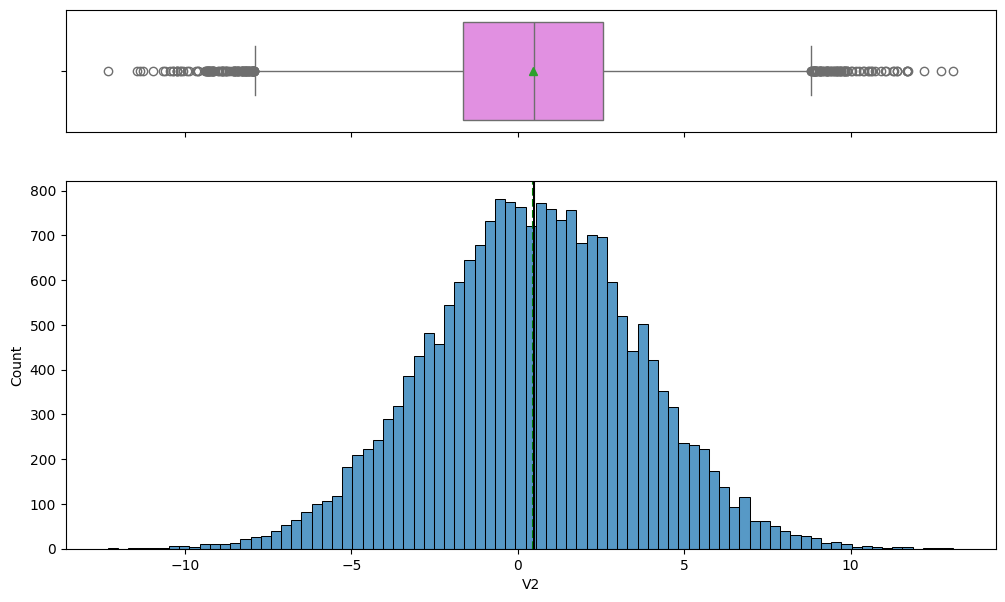

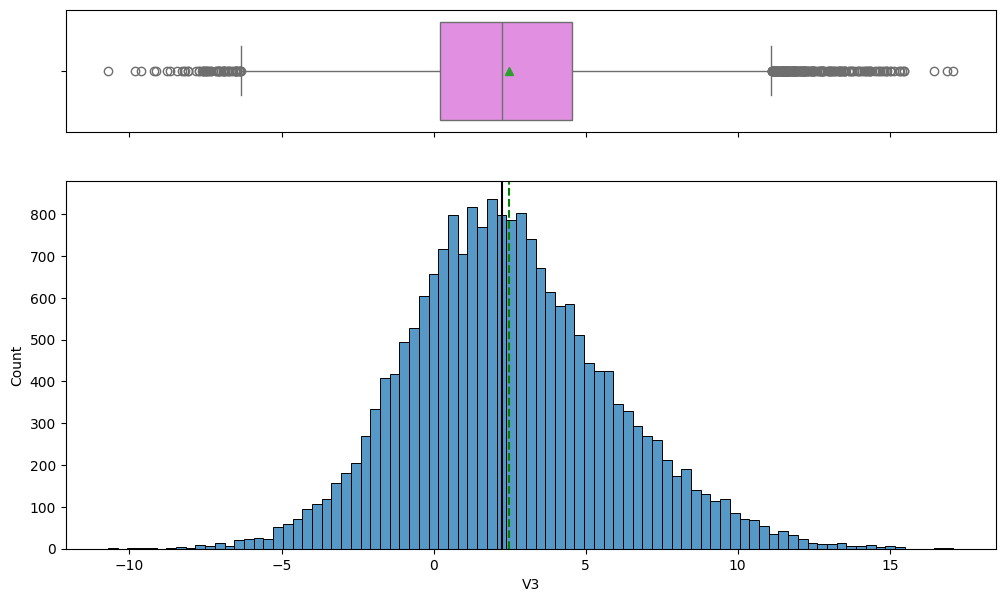

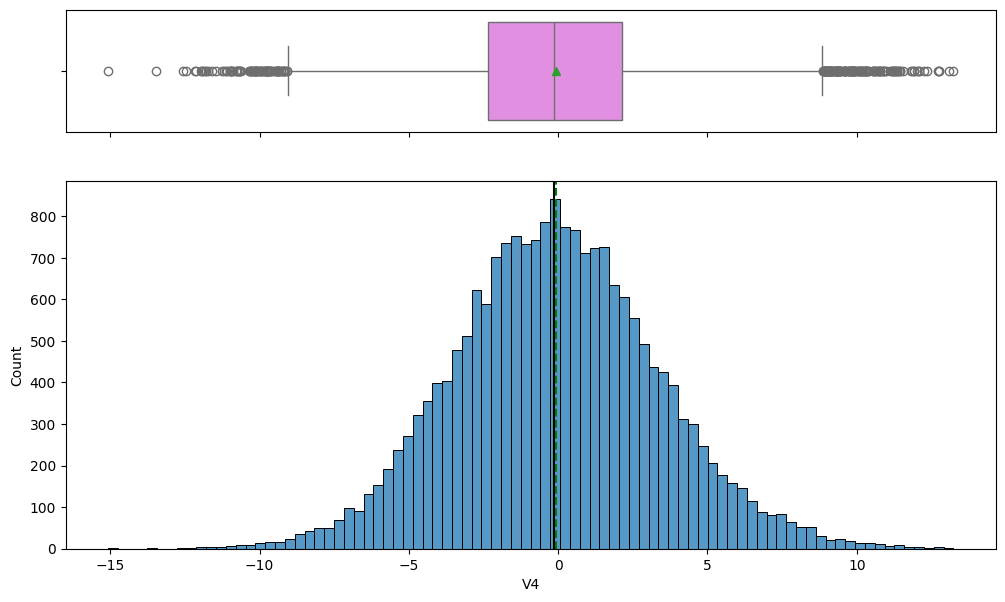

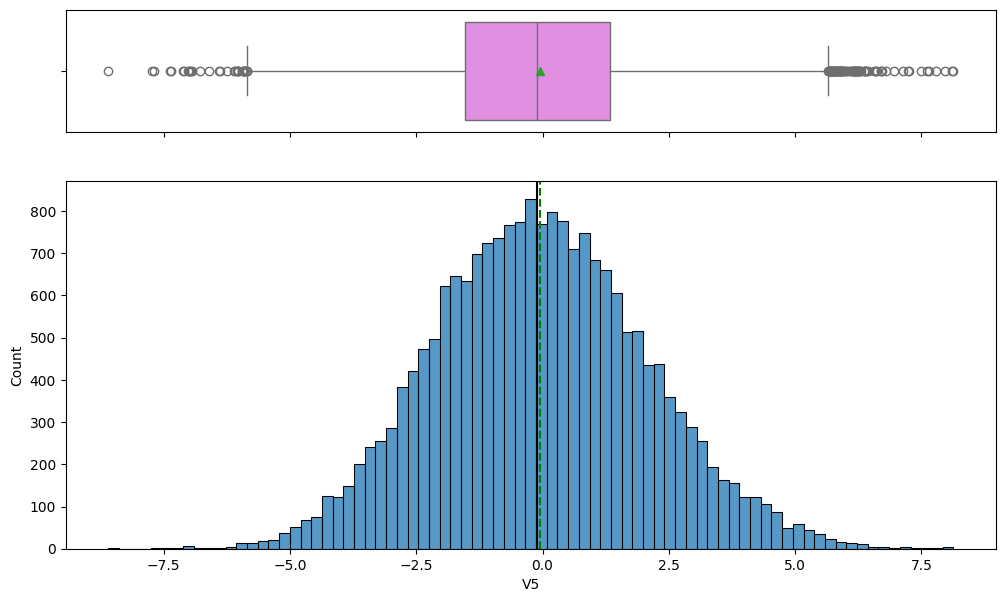

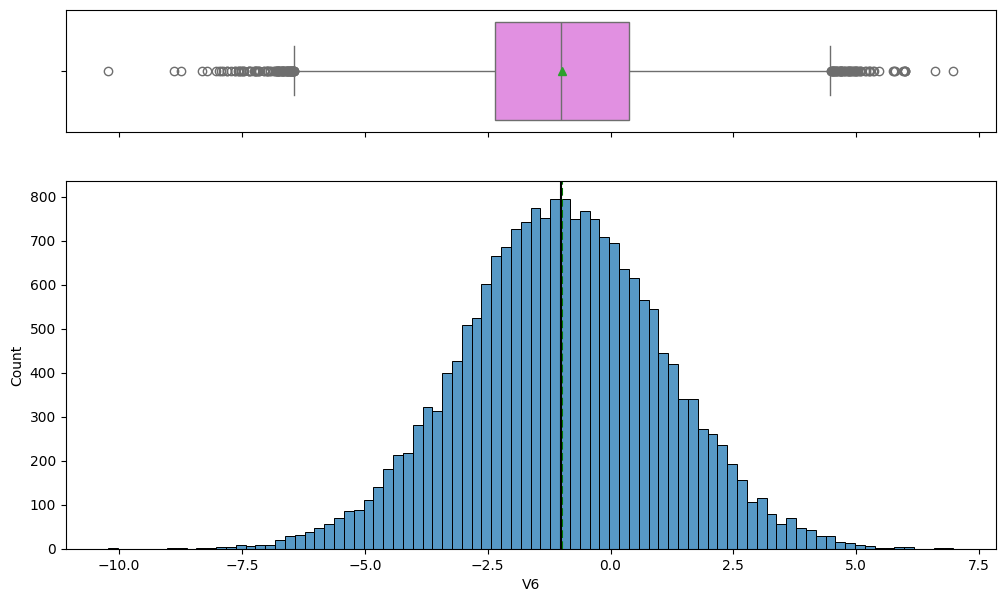

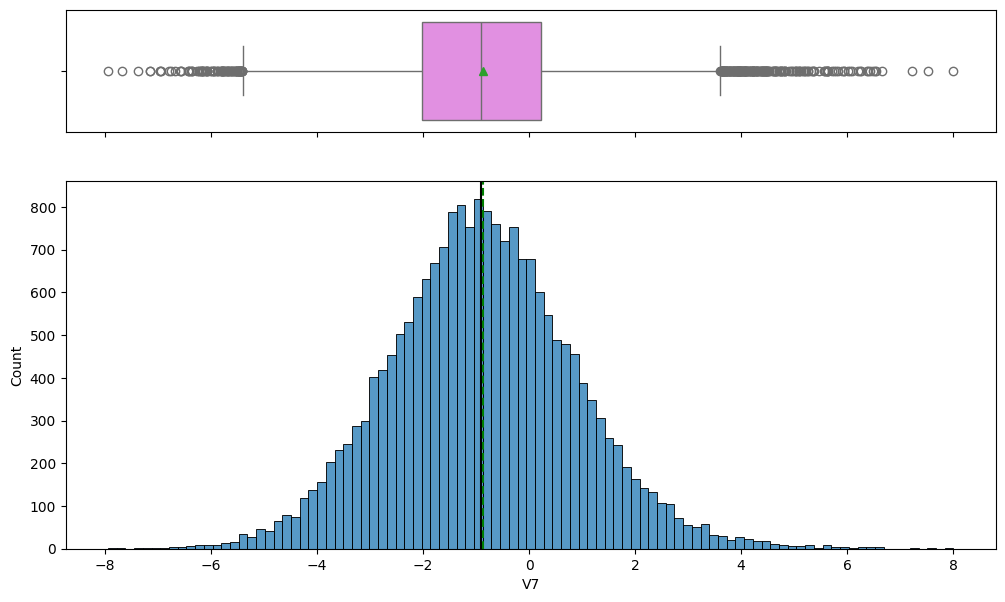

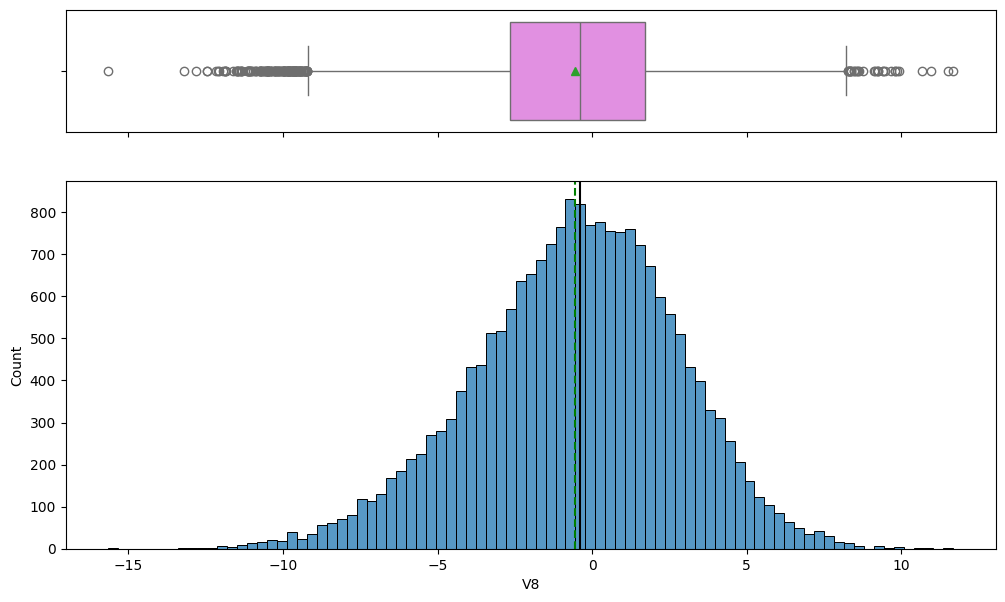

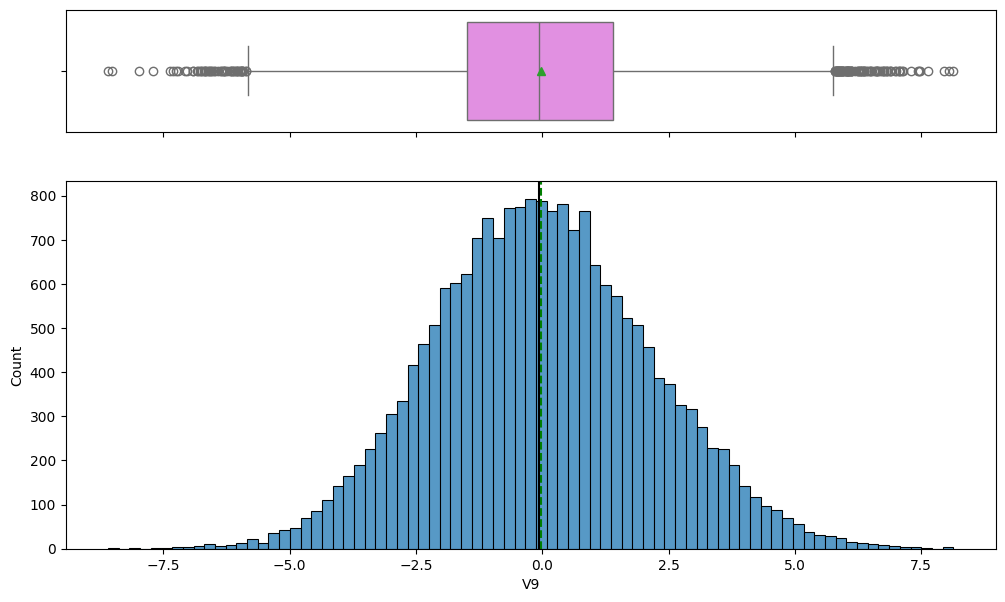

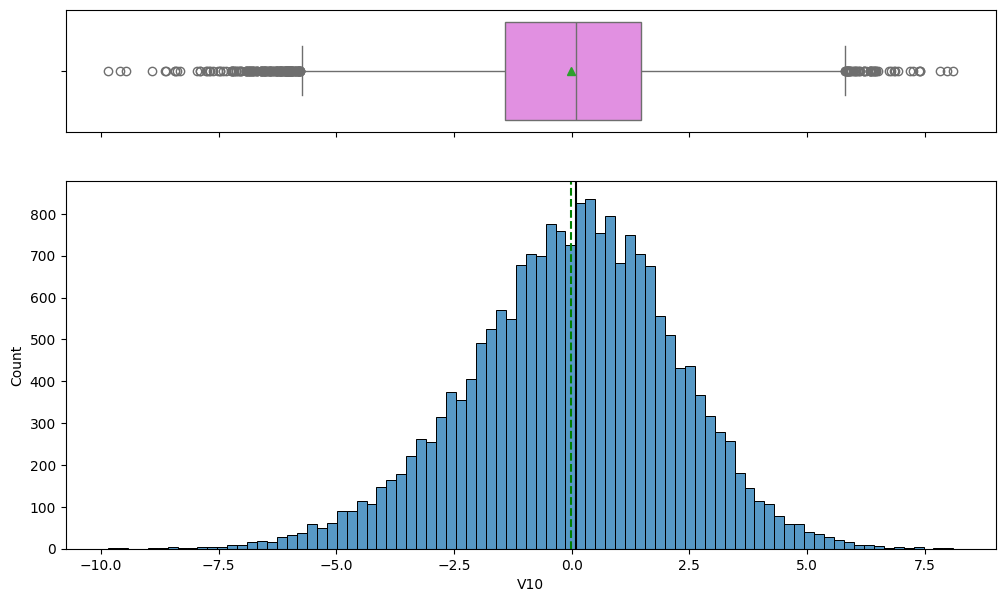

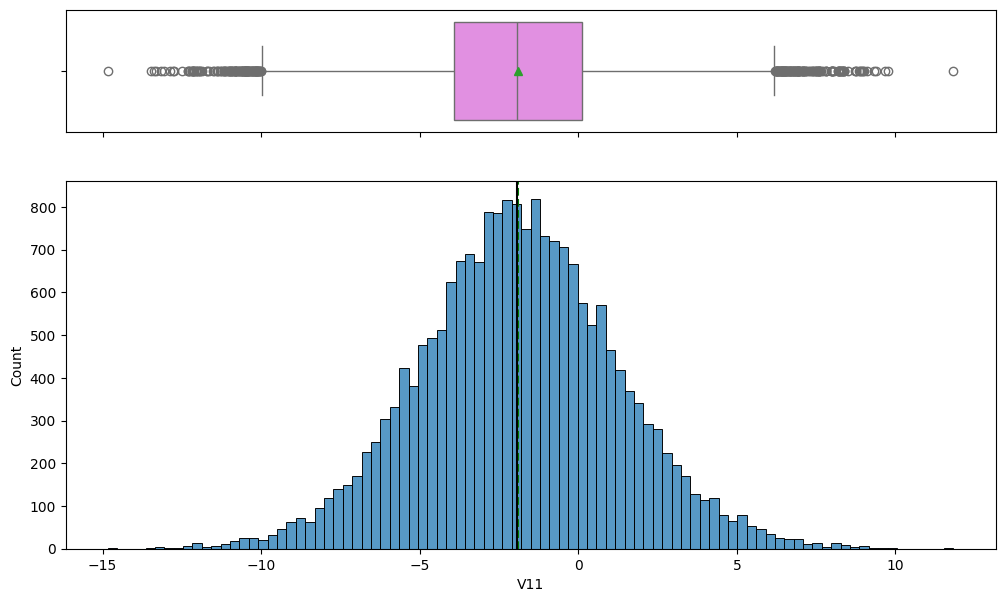

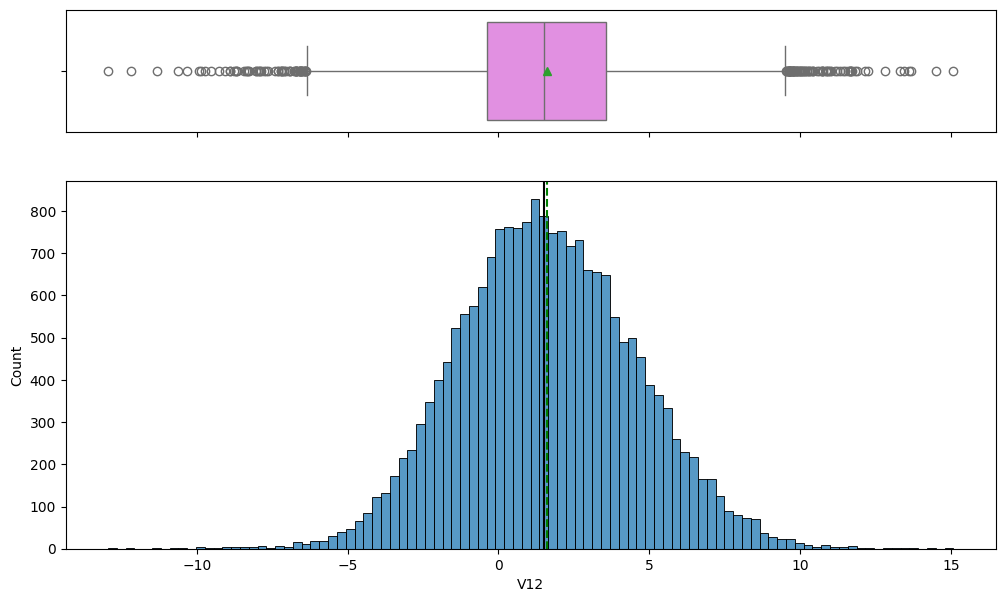

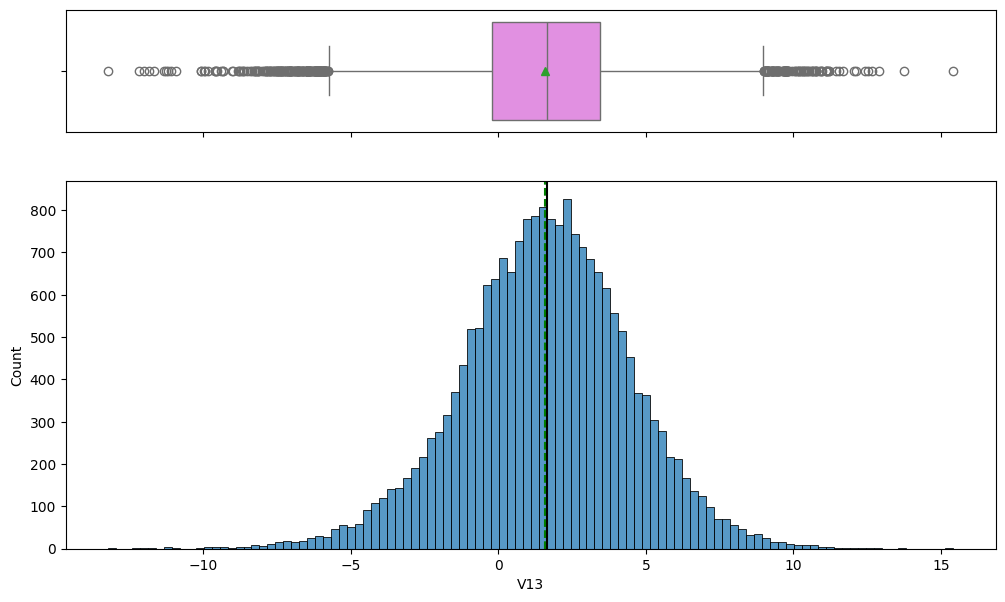

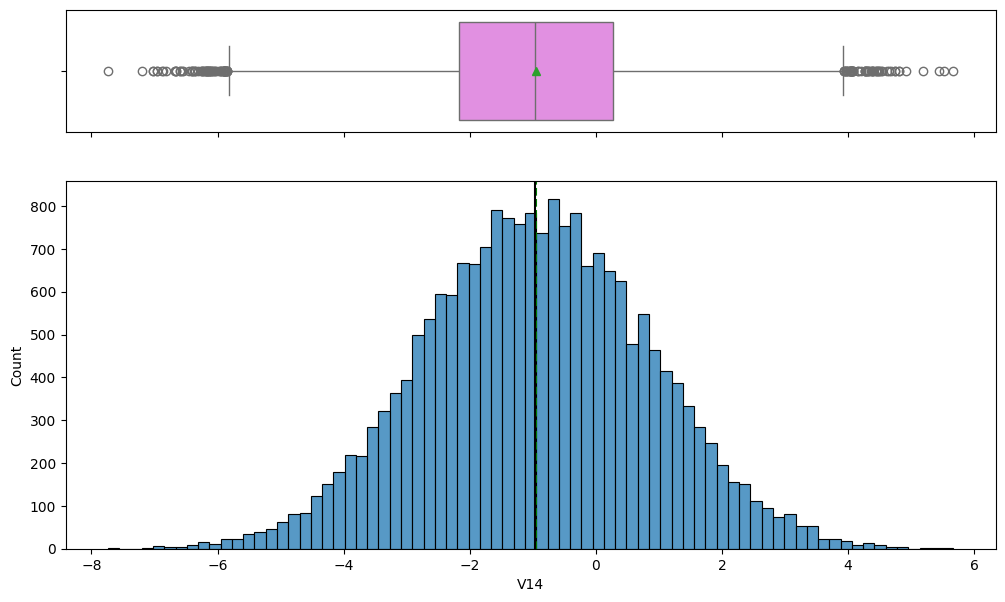

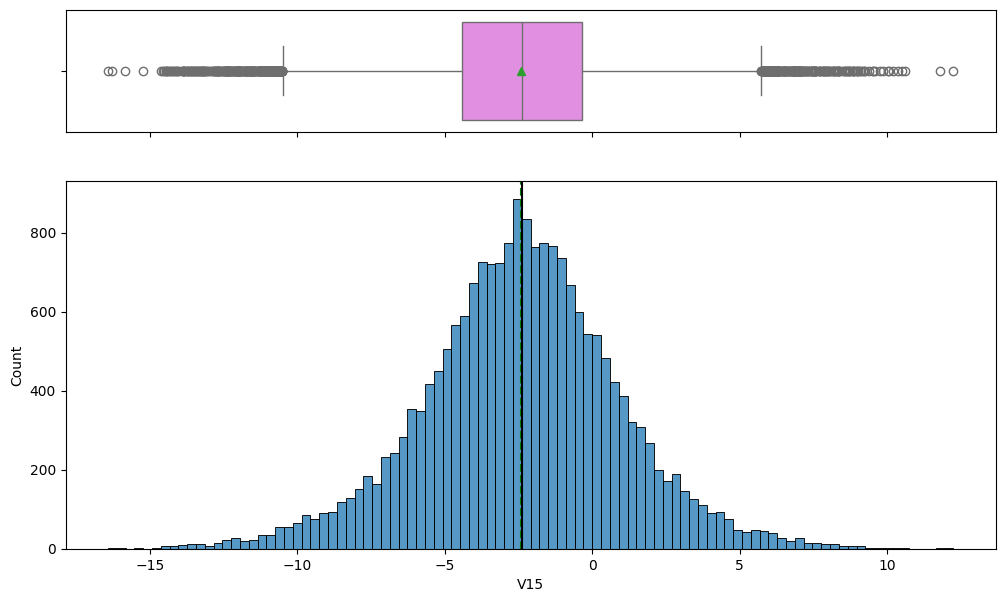

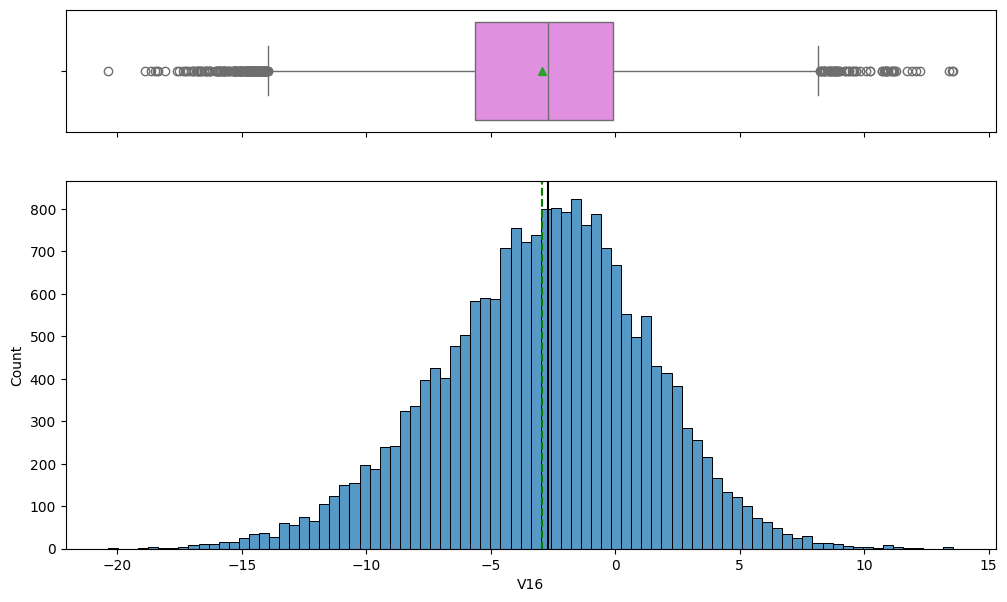

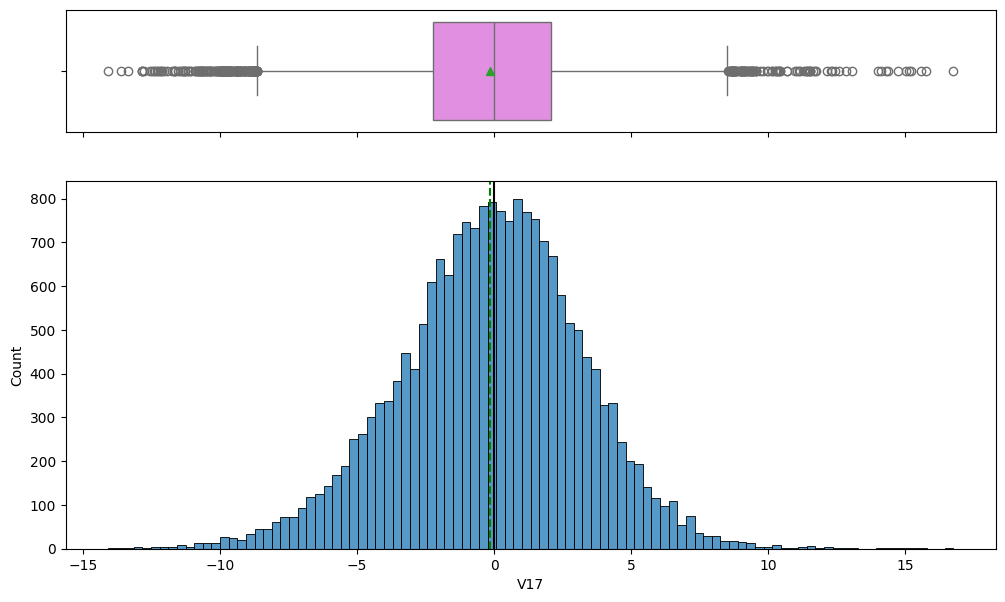

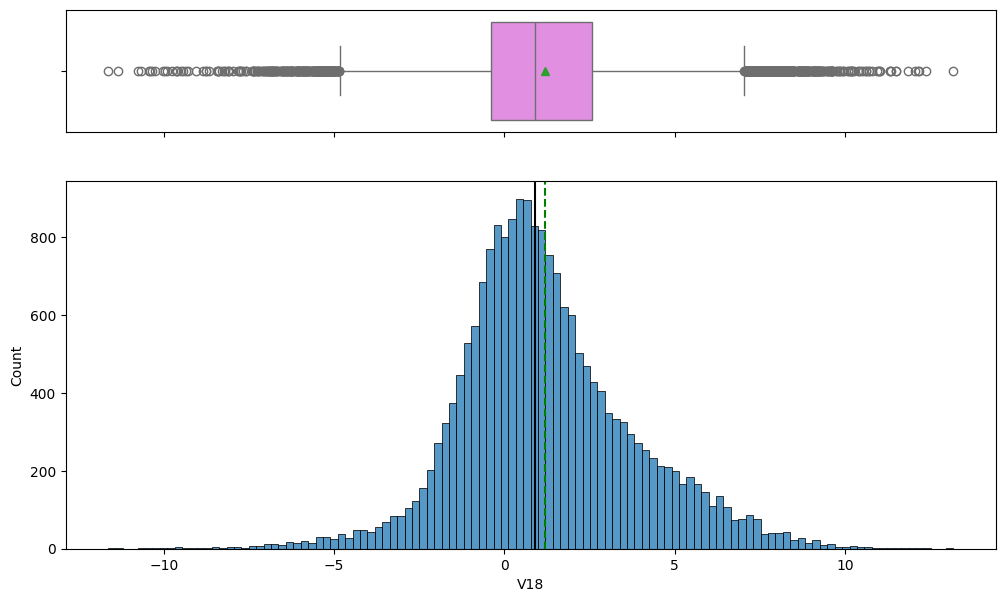

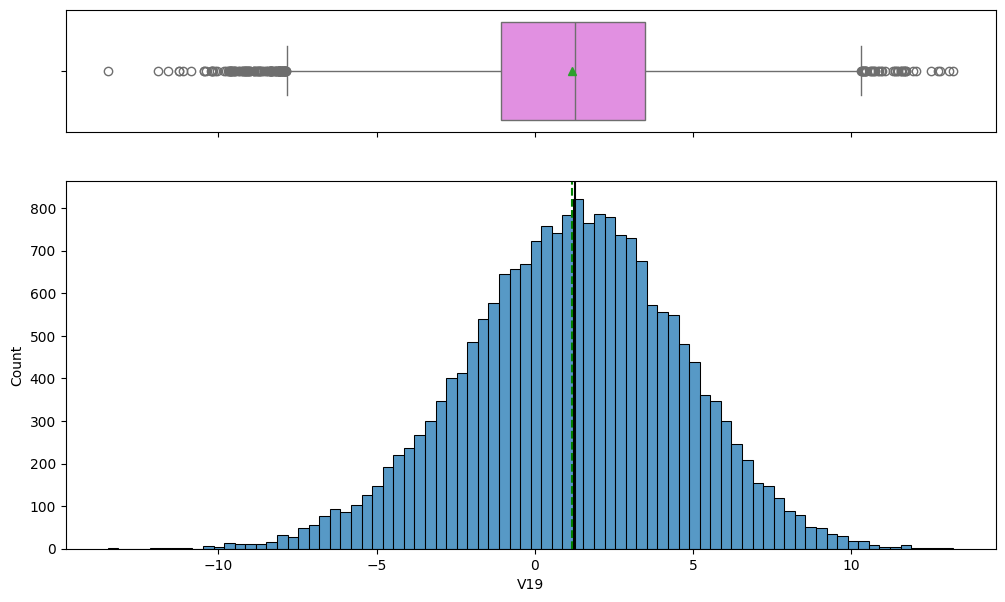

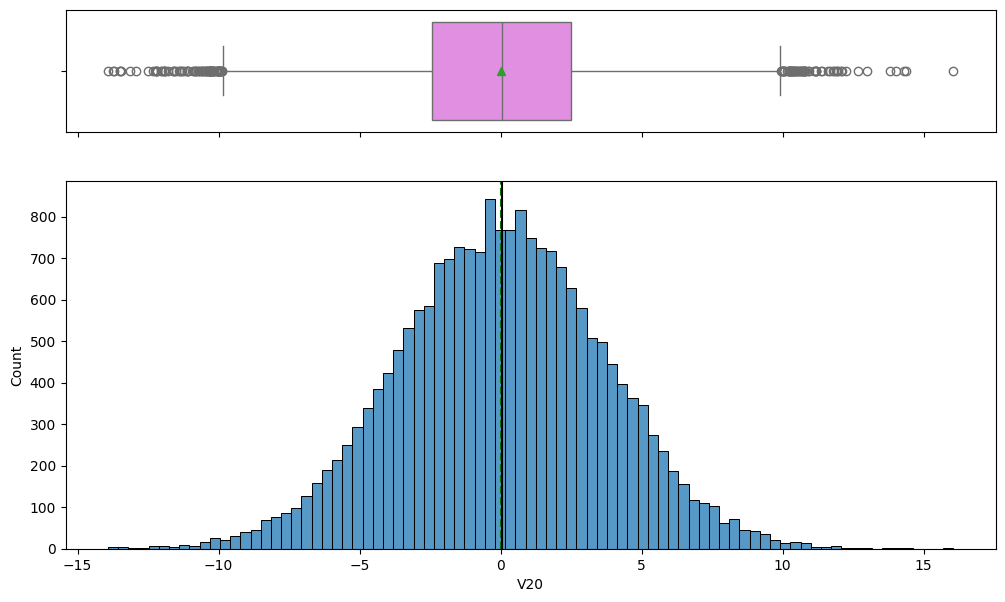

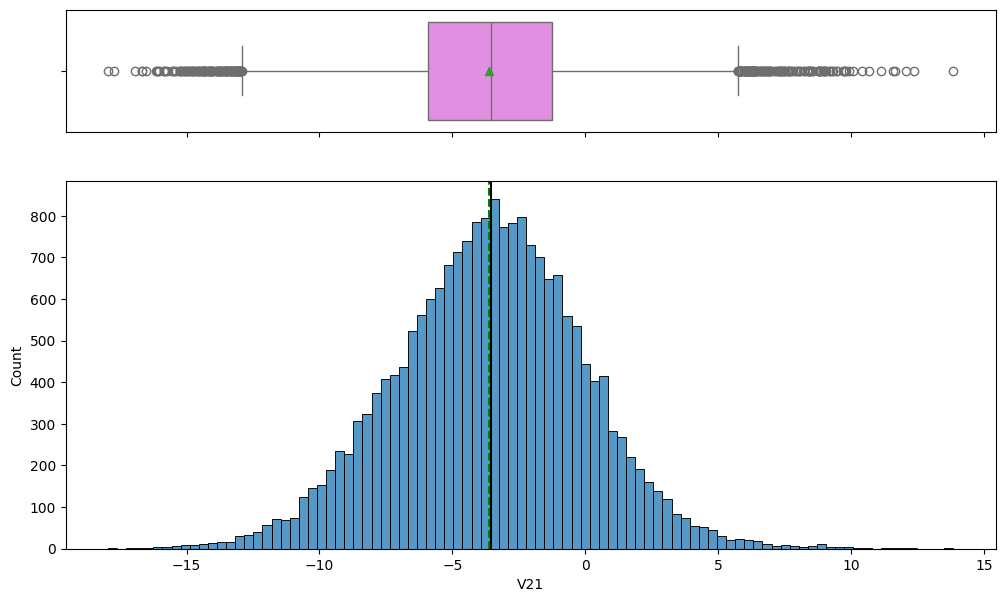

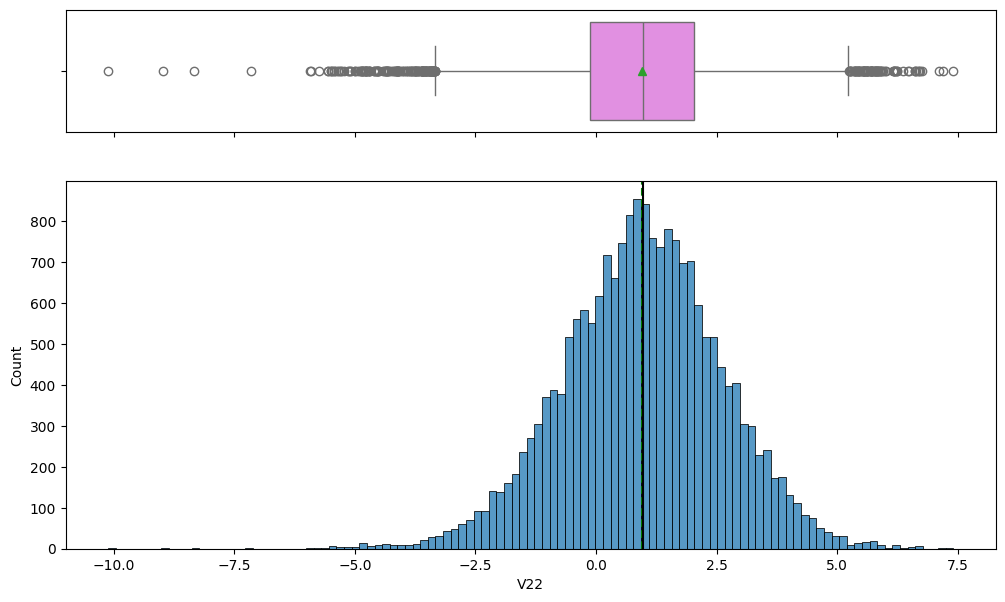

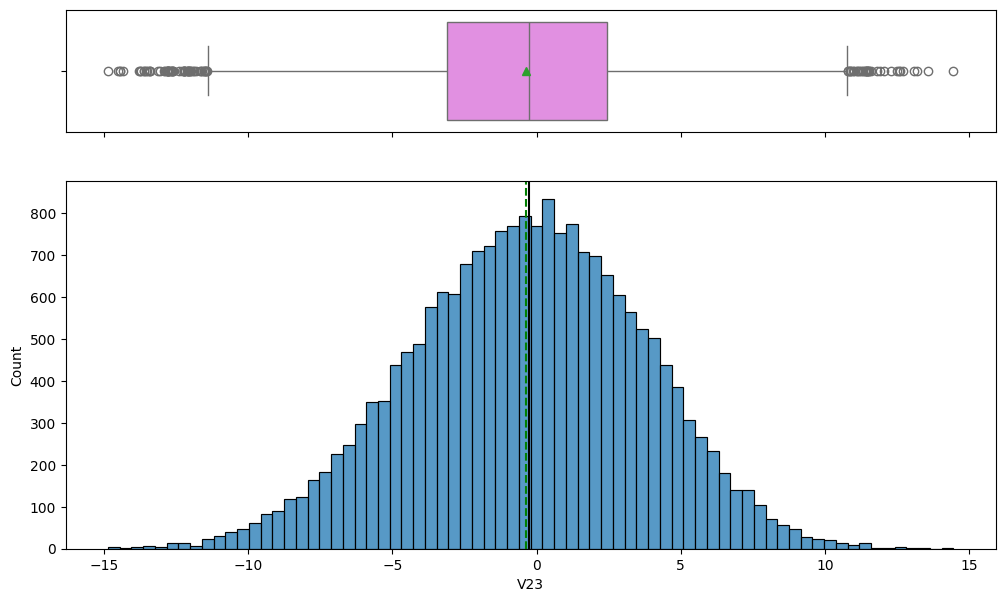

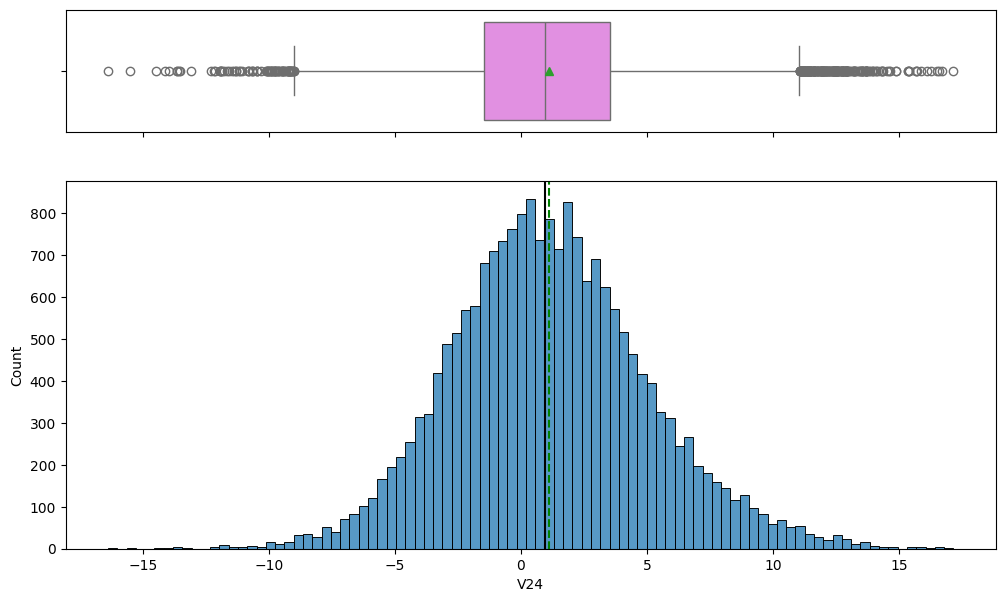

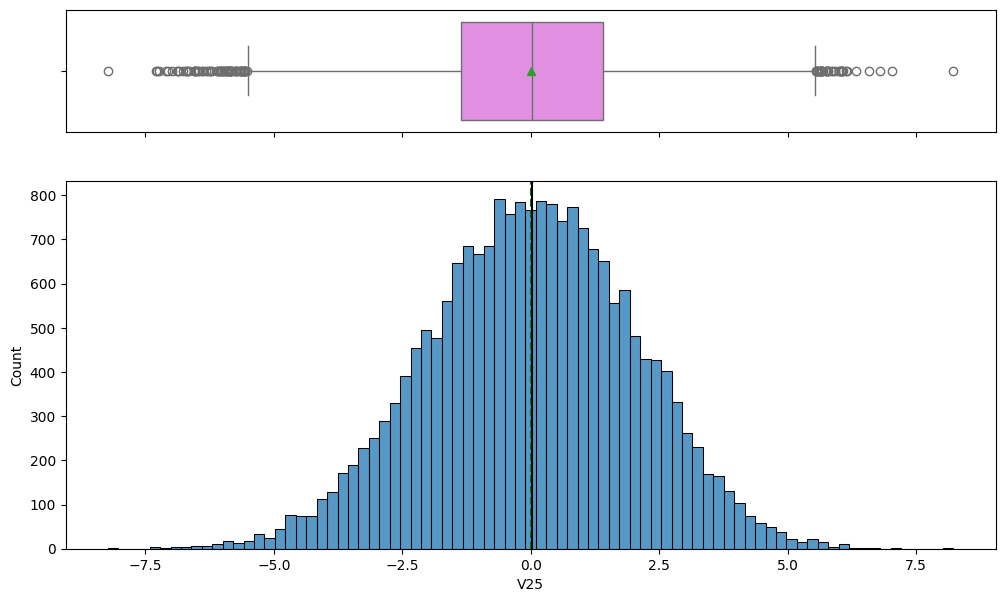

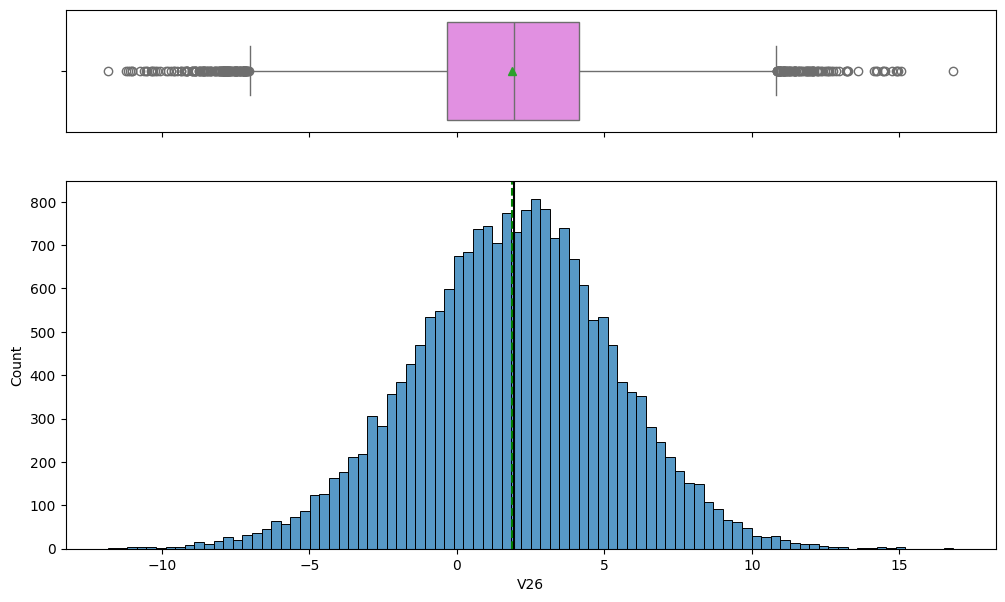

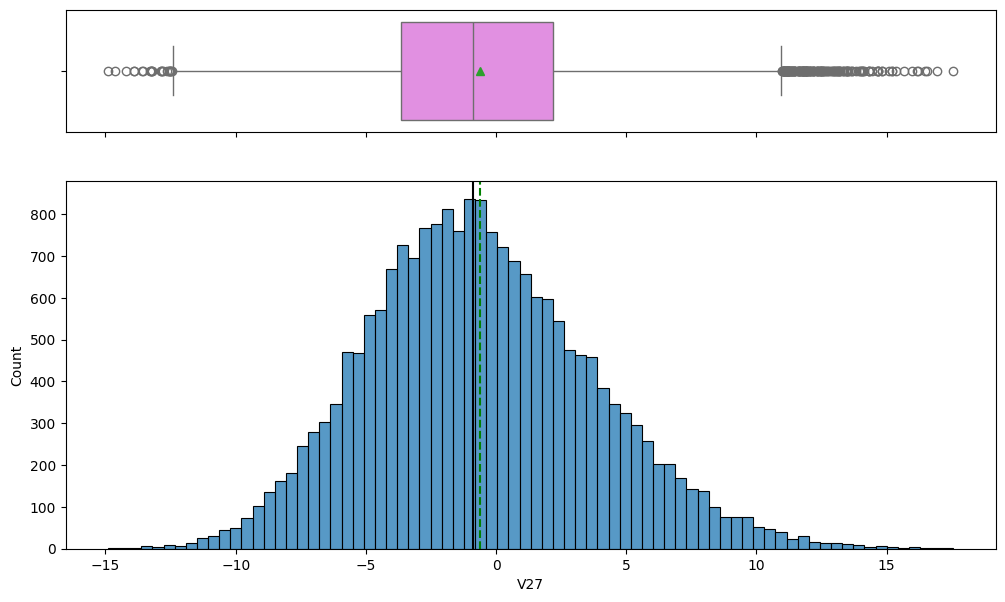

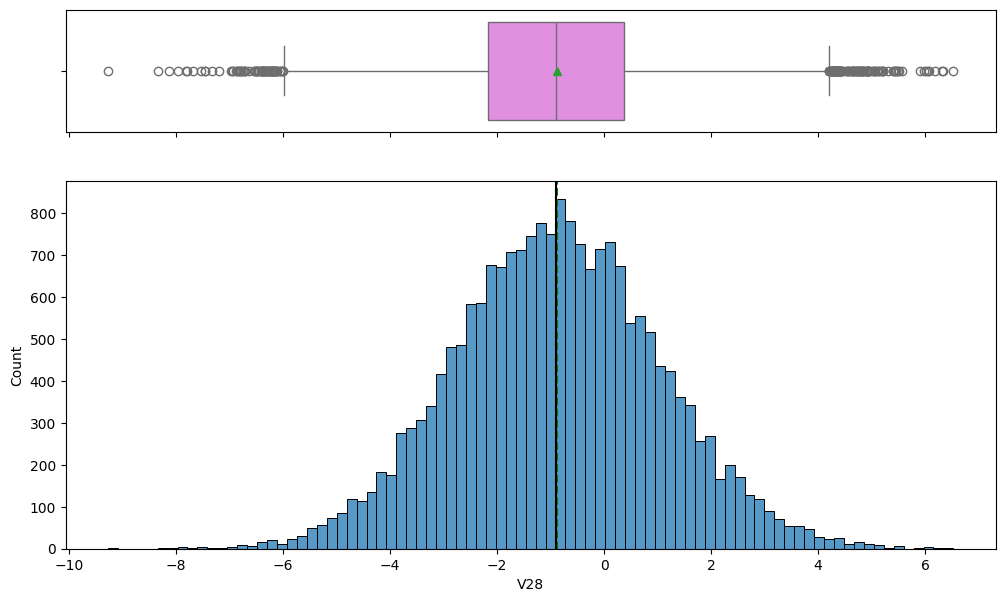

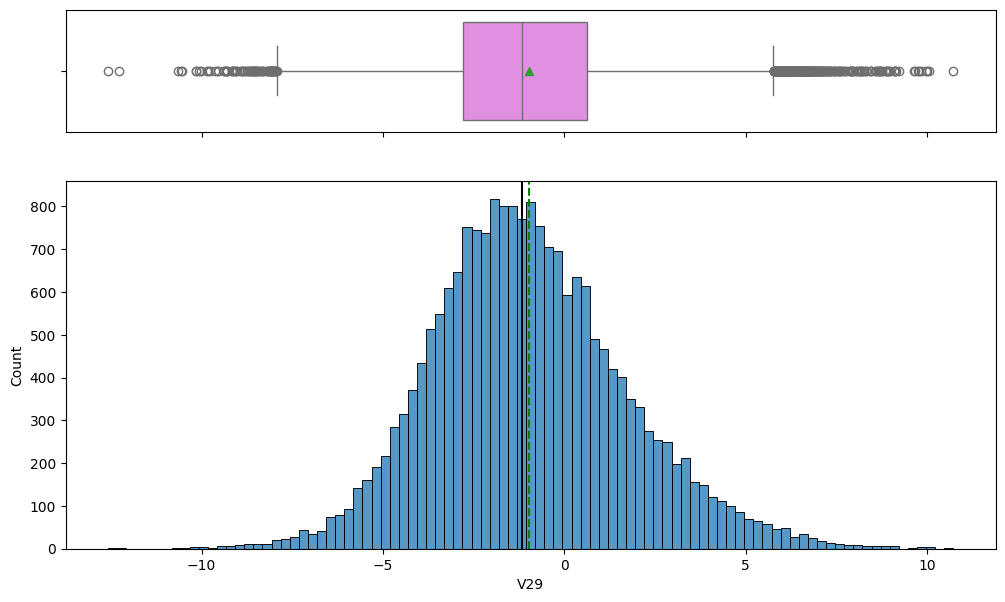

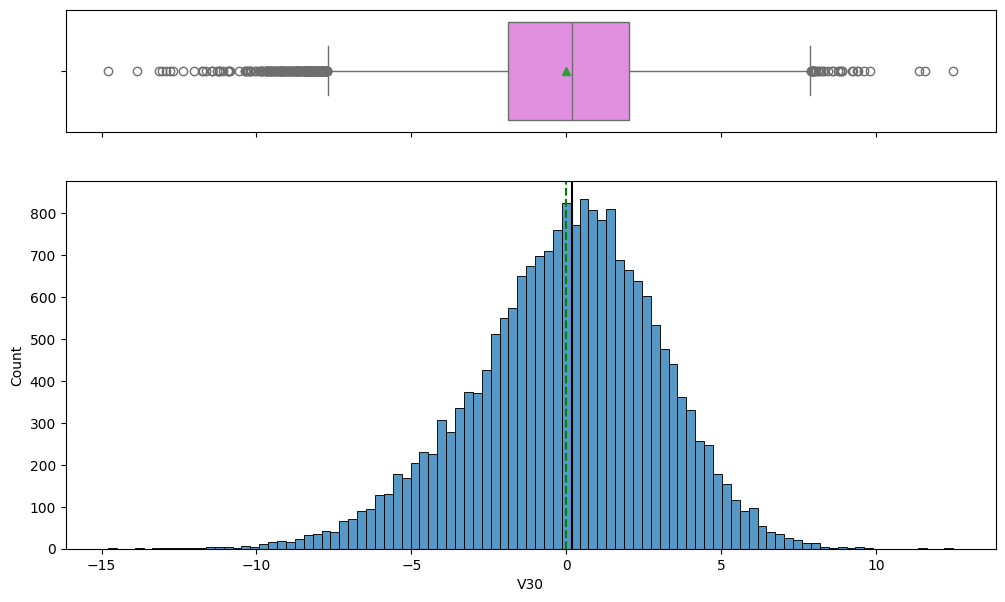

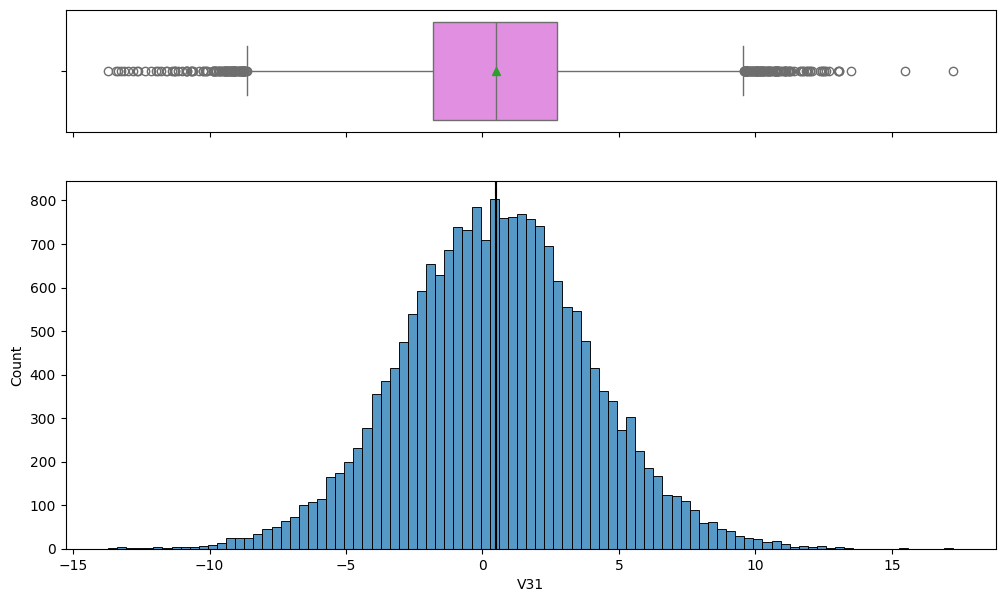

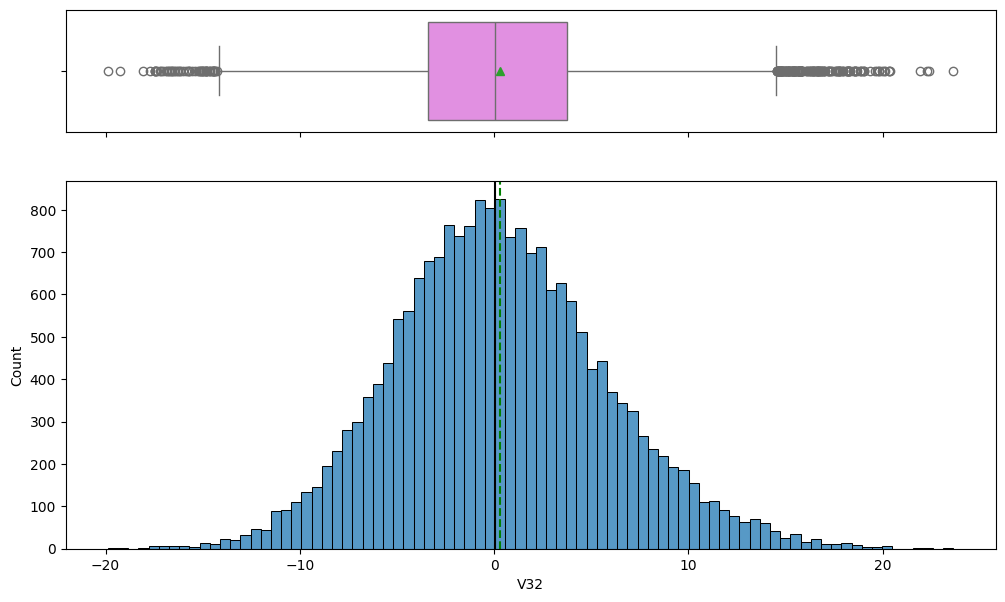

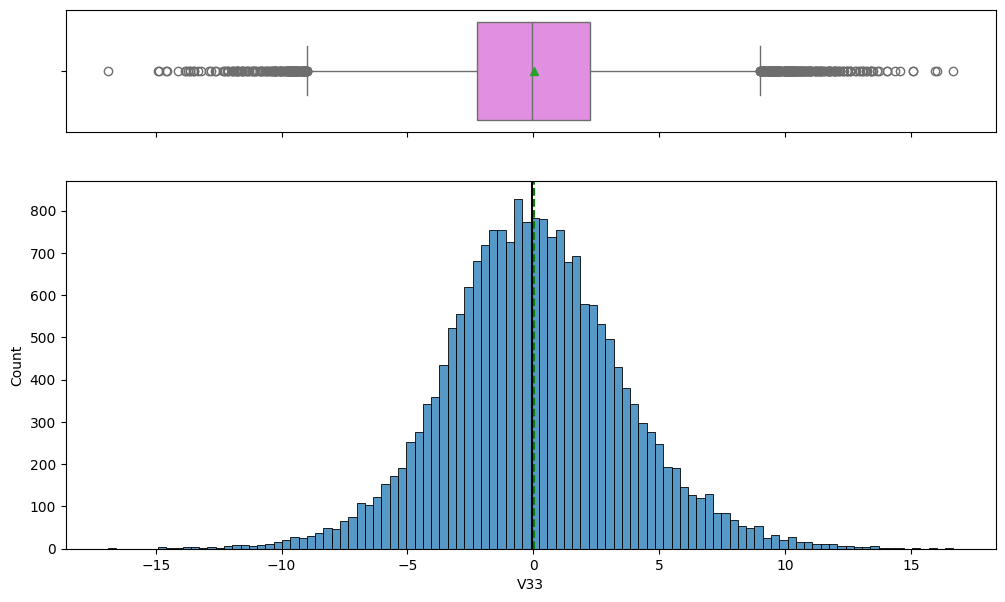

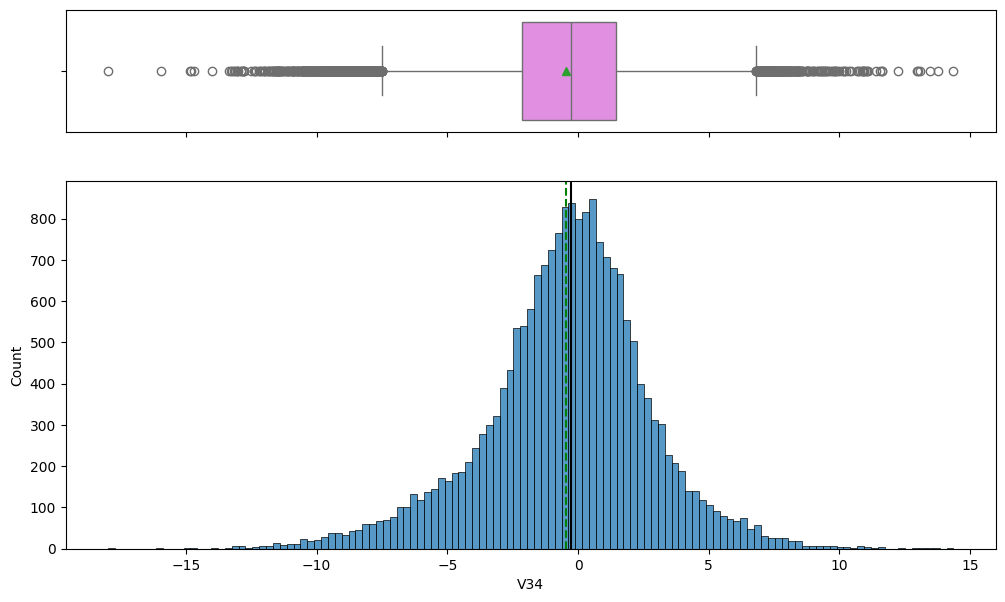

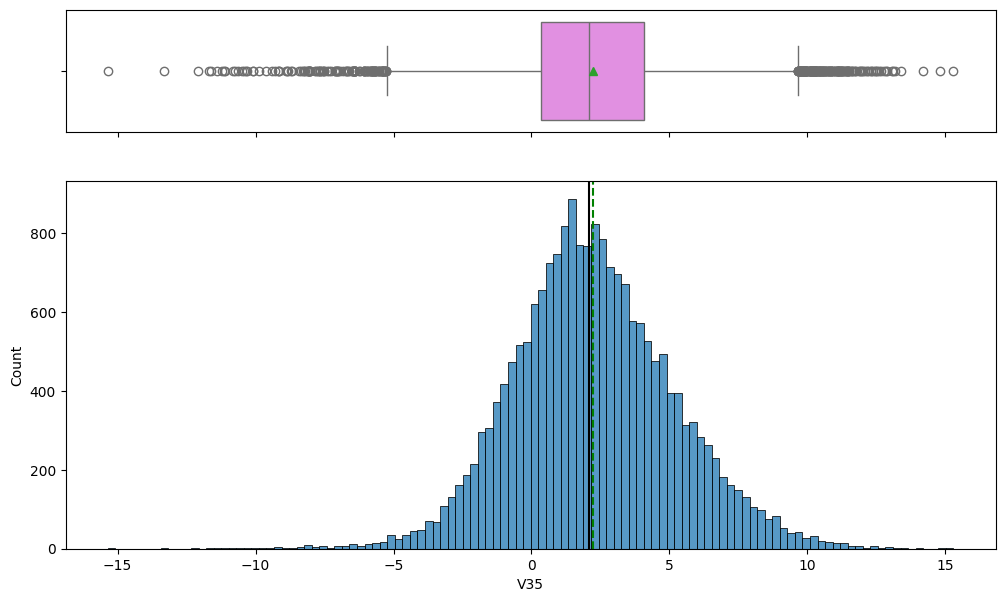

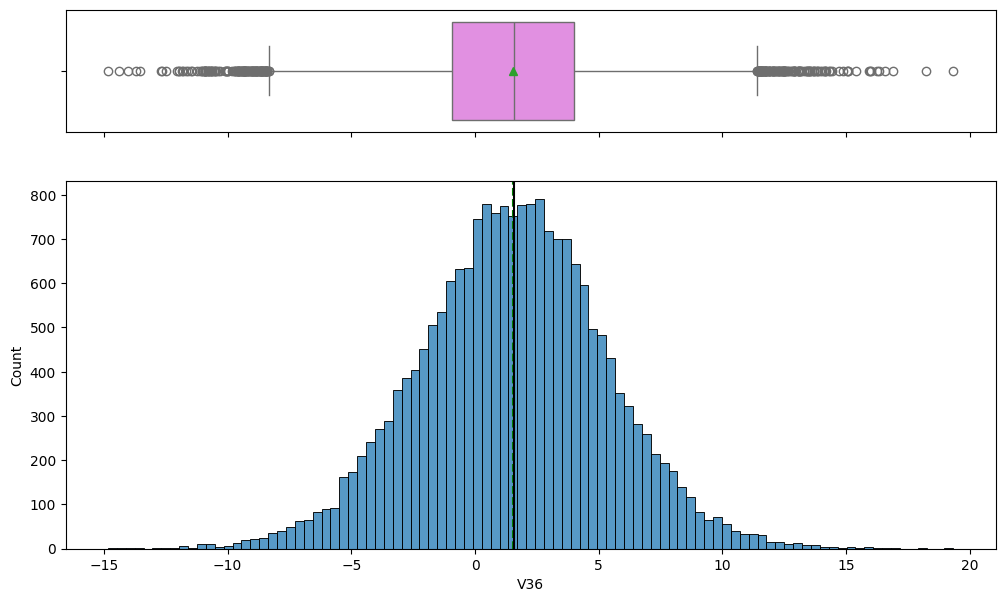

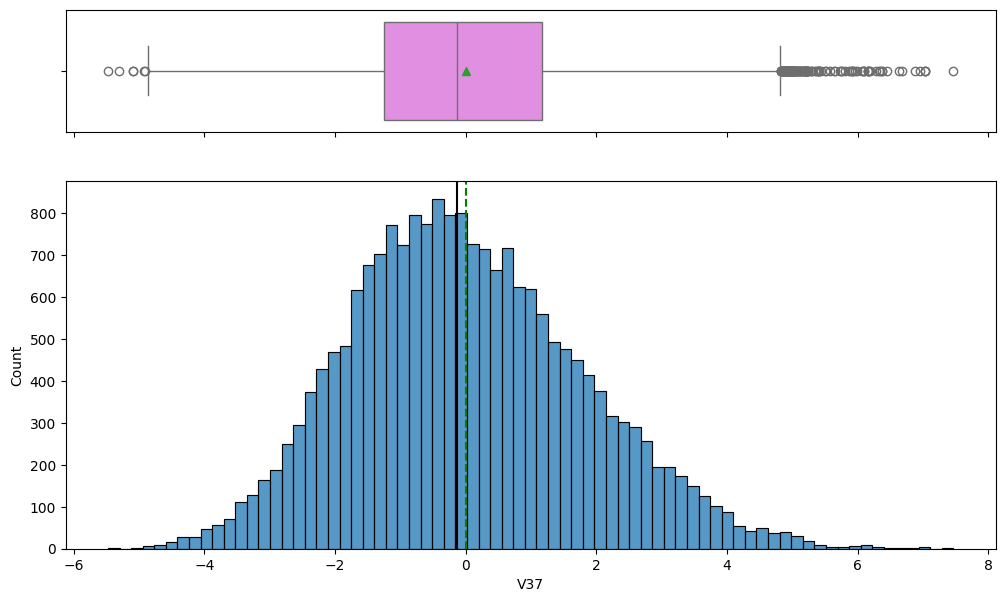

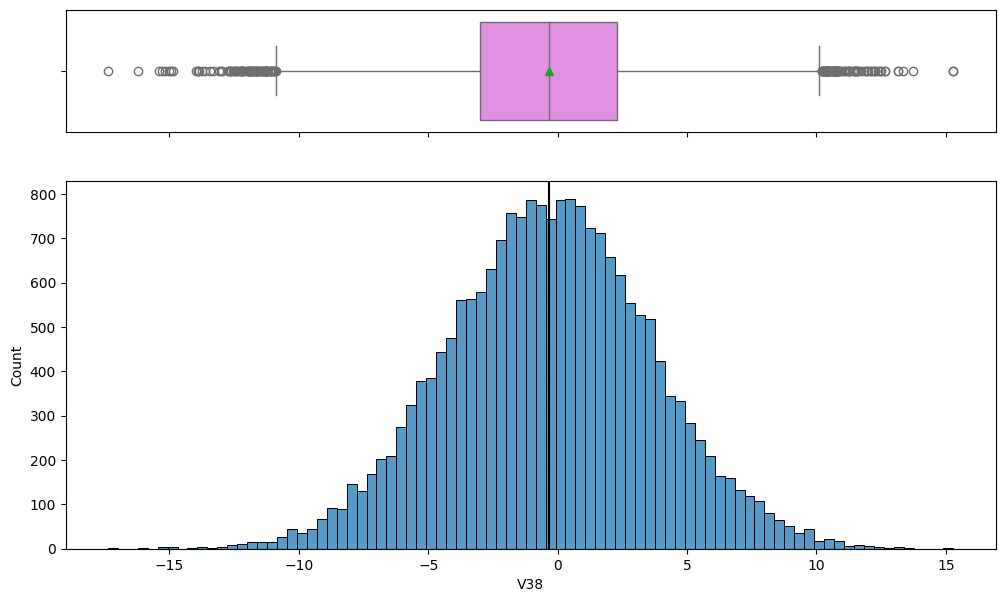

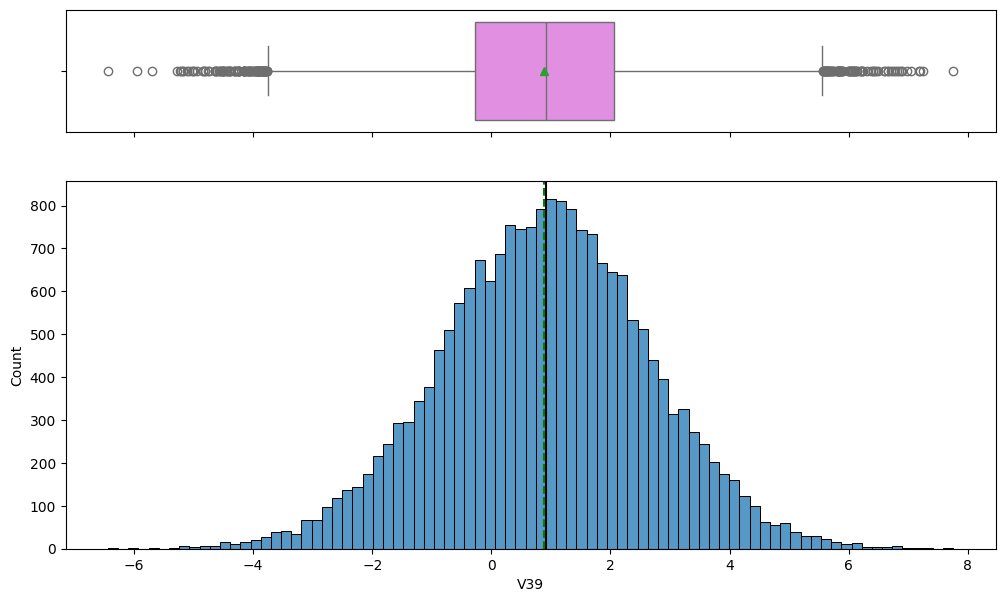

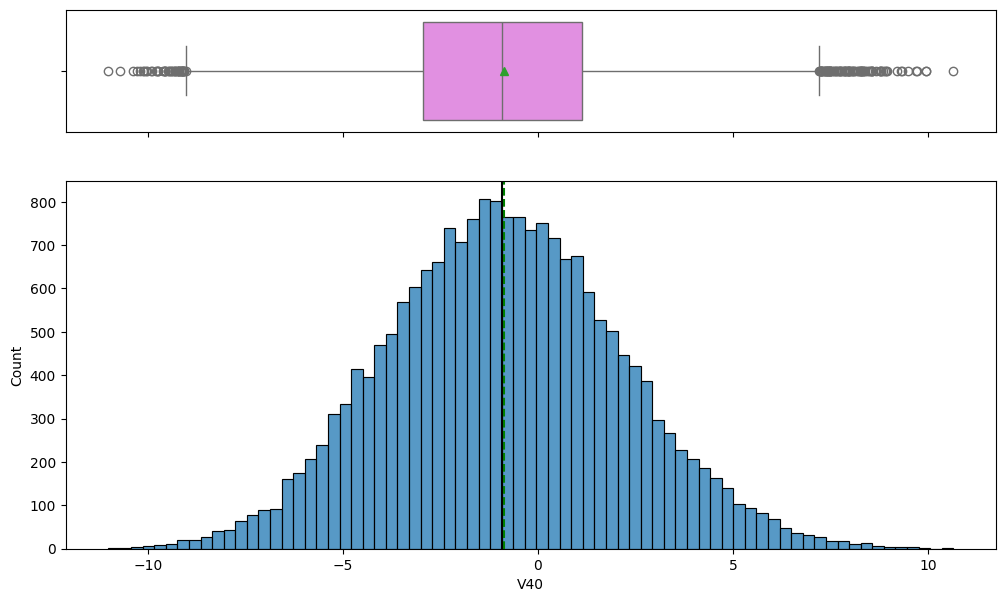

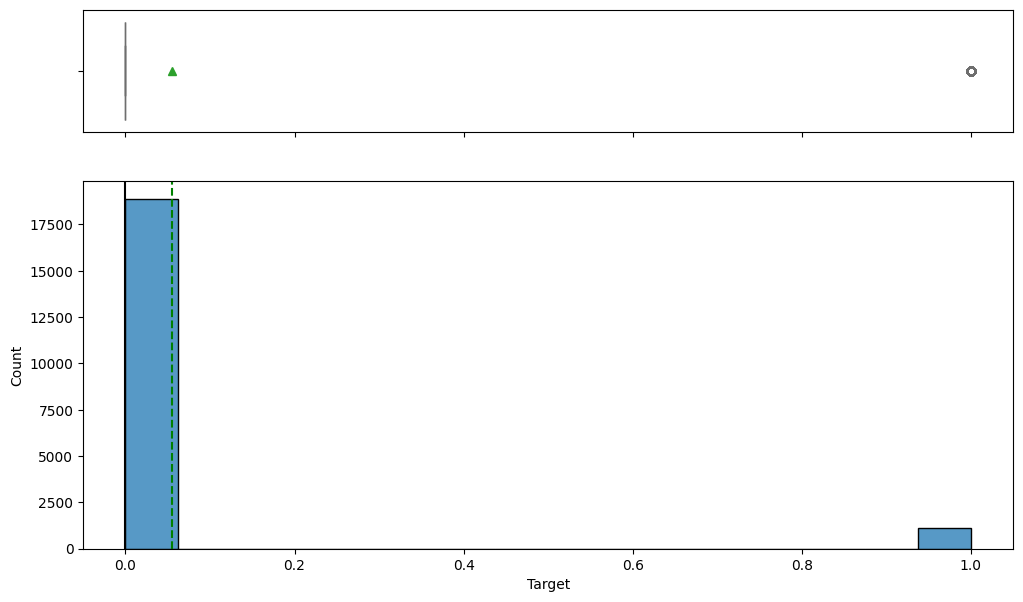

In [21]:
for feature in data.columns:
    histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None)

- The distribution of V1 – V40 are approximately bell-shaped, each variable showing various degrees of slight skewness (some to the left and others to the right).  
- The boxplots reveals the presence of several outliers on both ends.
- This indicates variability in operating conditions and highlights the need for robust modeling techniques that can handle skewness and outliers effectively.

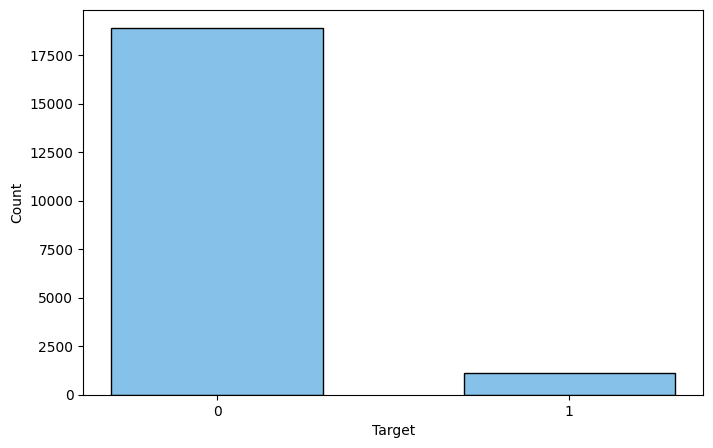

In [22]:
# 1. Ensure the Target is strictly binary (0 or 1)
# This prevents small decimals from creating unwanted extra bins
data['Target'] = data['Target'].round().astype(int)

# 2. Plot using histplot with 'shrink' and 'discrete' settings
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='Target', discrete=True, shrink=0.6, color='#5DADE2')

# Formatting to match your example
plt.xticks([0, 1])  # Ensures only 0 and 1 appear on the axis
plt.xlabel('Target')
plt.ylabel('Count')

plt.show()

In [23]:
# Print the count of each target variable
target_counts = data['Target'].value_counts()
print(target_counts)

# To see the proportions (percentages) as well:
target_proportions = data['Target'].value_counts(normalize=True)
print("\nProportions:")
print(target_proportions)

Target
0    18890
1     1110
Name: count, dtype: int64

Proportions:
Target
0    0.9445
1    0.0555
Name: proportion, dtype: float64


### Checking the distrubution of Target variable

In [24]:
# For train data
data["Target"].value_counts(1)

,proportion
Target,
0,0.9445
1,0.0555


Distribution of Target Variable (Train Data)
- 18890 (94.45%) of the distribution show No failure (0).  
- 1110 (5.55%) of the distribution show Failure (1).


In [25]:
# For test data
df_test["Target"].value_counts(1) # Complete the code to display the proportion of the target variable in the test data

,proportion
Target,
0,0.9436
1,0.0564


- Test data has approximately the same distribution (94.36% for No Failure and 5.64% for Failure)

## Bivariate Analysis

### Correlation Check

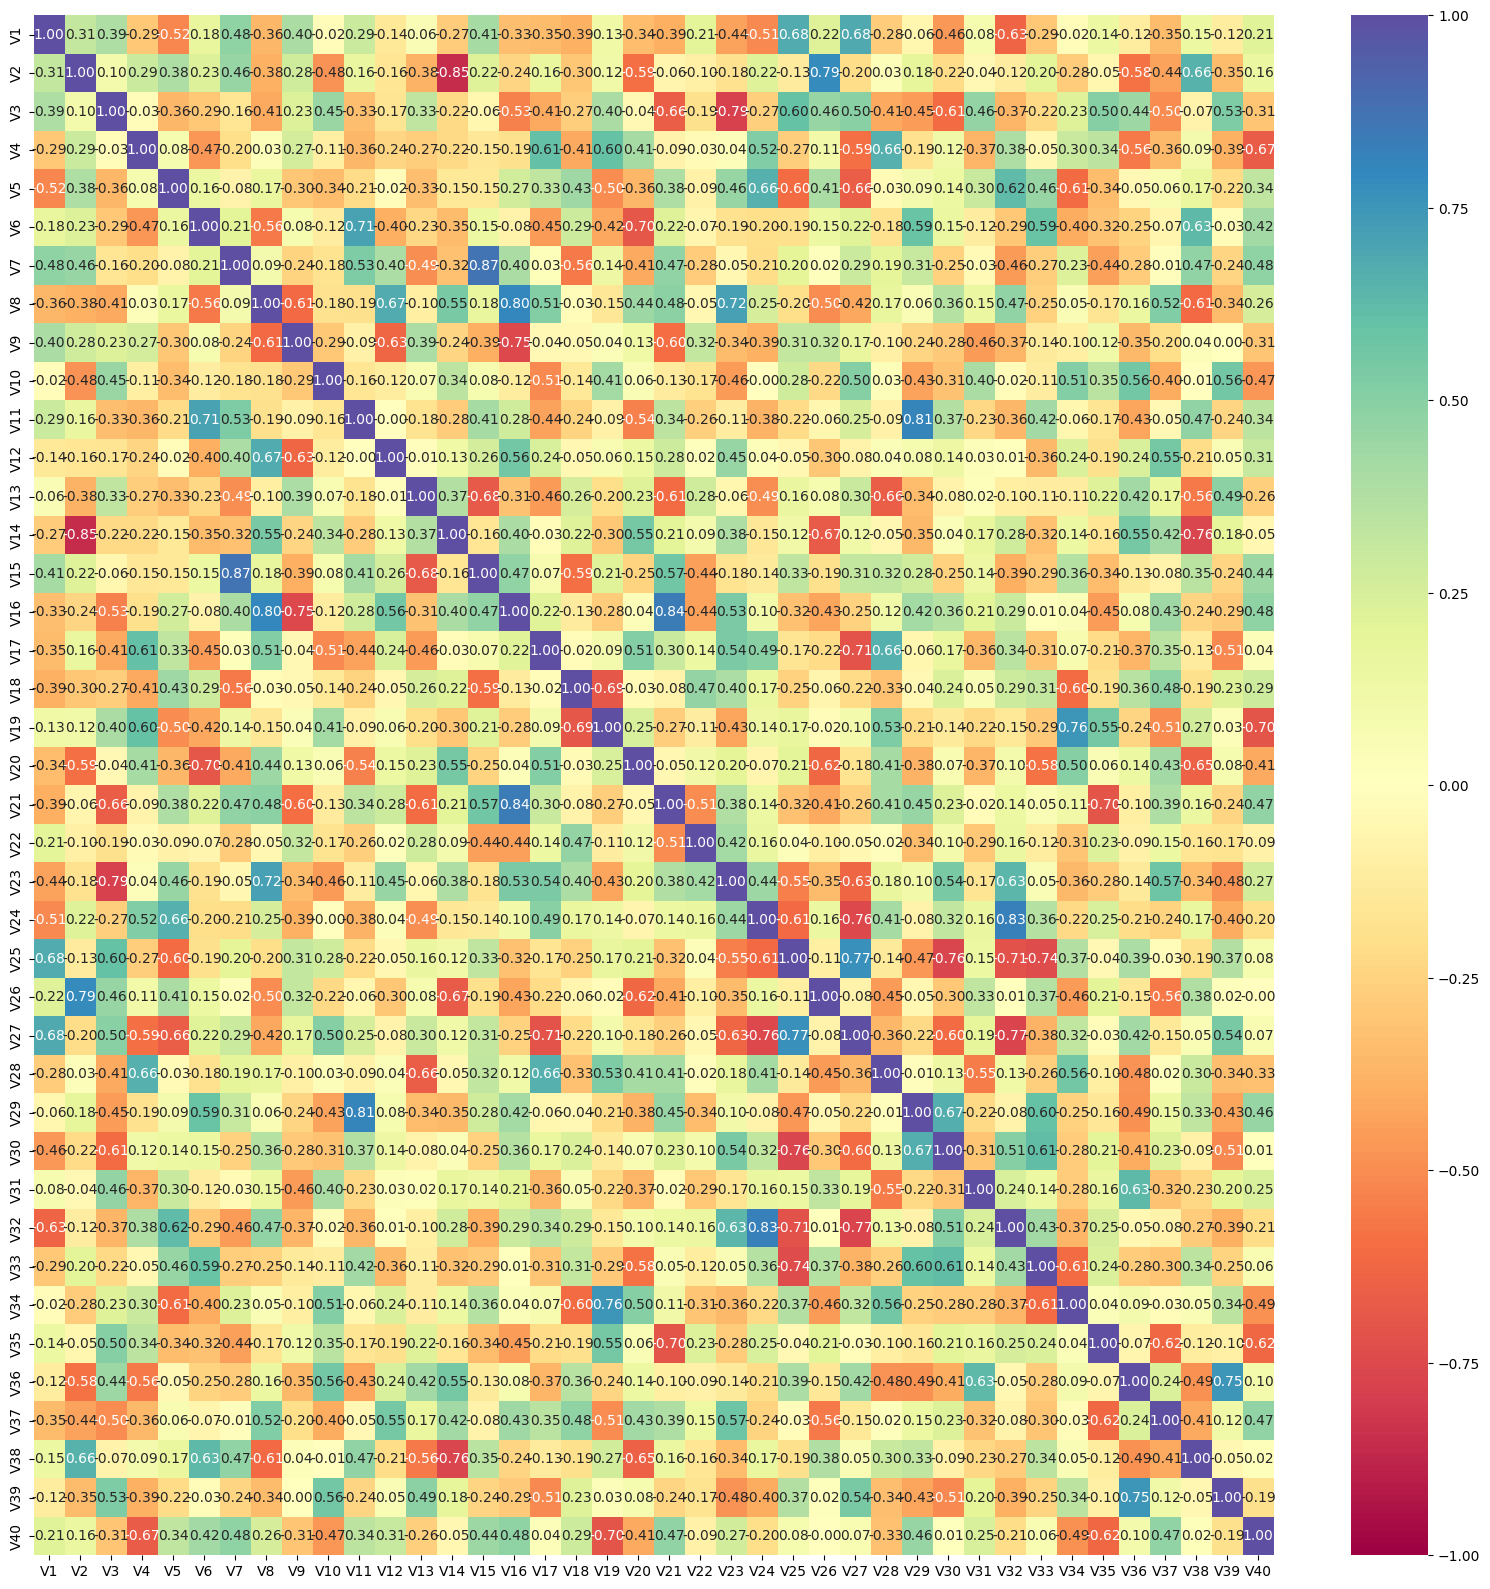

In [26]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()
cols_list.remove("Target")

plt.figure(figsize=(20, 20))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

The correlation heat map shows that most variables have low to moderate correlations, indicating limited multicollinearity across the dataset.

- The following variable pairs exhibit the highest positive correlations: V7 & V15 (0.87), V16 & V21 (0.84), V24 & V32 (0.83), V11 & V29 (0.81), V8 & V16 (0.8)
- The following variable pairs exhibit the highest negative correlations: V2 & V14 (-0.85), V3 & V23 (-0.79), V27 & V32 (-0.77), V14 & V48 (-0.76), V9 & V16 (-0.75).




# **Data Preprocessing**

## Data Preparation for Modeling

In [27]:
# Dividing train data into X and y
X = data.drop(columns = ["Target"] , axis=1)
y = data["Target"]

**Since we already have a separate test set, we don't need to divide data into train, validation and test**


In [28]:
# Splitting data into training and validation set:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)



*   The train set is split into training set (80%) and validation set (20%)

In [29]:
# Checking the number of rows and columns in the X_train data
X_train.shape

(16000, 40)

*   The train set has 16000 rows and 40 columns

In [30]:
# Checking the number of rows and columns in the X_val data
X_val.shape

(4000, 40)

*   The validation set has 4000 rows and 40 columns




In [31]:
# Dividing test data into X_test and y_test
X_test = data_test.drop(columns = ['Target'] , axis= 1)
y_test = data_test["Target"]

In [32]:
# Checking the number of rows and columns in the X_test data
X_test.shape

(5000, 40)

*   The test set has 5000 rows and 40 columns

## Missing Value Imputation


- There were few missing values in V1 and V2, we will impute them using the median.
- And to avoid data leakage we will impute missing values after splitting train data into train and validation sets.




In [33]:
imputer = SimpleImputer(strategy="median")

In [34]:
# Fit and transform the train data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Transform the validation data
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_train.columns)

# Transform the test data
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

In [35]:
# Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22

- There are no missing values in the train, validate and test data sets

In [36]:
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

# **Model Building**

## Model Evaluation Criterion

Model can make wrong predictions as:
- Predicting a generator will not fail but in reality, the generator will fail (FN)
- Predicting a generator will fail but in reality, the generator will not fail (FP)
Which case is more important?
- If we predict that a generator will not fail, but it actually fails, the company incurs repair or replacement costs and downtime losses.
- If we predict that a generator will fail, but it actually does not fail, the company only incurs inspection costs.
- The cost of repairing a generator is much lower than replacing it, and the cost of inspection is lower than the cost of repair.
How to reduce the losses?
- The aim would be to maximize Recall, as a higher Recall reduces the number of False Negatives.

## Utility Functions

In [37]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [38]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='macro')  # to compute Recall
    precision = precision_score(target, pred, average='macro')  # to compute Precision
    f1 = f1_score(target, pred, average='macro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,}, index = [0]
    )

    return df_perf

## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer of 7 neurons respectively
  - activation function of ReLU.
  - SGD as the optimizer

In [39]:
# defining the batch size and # epochs upfront as we'll be using the same values for all models
epochs = 25
batch_size = 50

In [40]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [41]:
#Initializing the neural network
model_0 = Sequential()
model_0.add(Dense( 7,activation="relu",input_dim=X_train.shape[1]))
model_0.add(Dense( 1,activation="sigmoid"))

In [42]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
model_0.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])


In [44]:
start = time.time()
history = model_0.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.1396 - loss: 0.2297 - val_Recall: 0.2162 - val_loss: 0.1606
Epoch 2/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.2815 - loss: 0.1454 - val_Recall: 0.3829 - val_loss: 0.1313
Epoch 3/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.3874 - loss: 0.1247 - val_Recall: 0.4414 - val_loss: 0.1196
Epoch 4/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.4448 - loss: 0.1141 - val_Recall: 0.5000 - val_loss: 0.1109
Epoch 5/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.4887 - loss: 0.1068 - val_Recall: 0.5495 - val_loss: 0.1052
Epoch 6/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.5214 - loss: 0.1017 - val_Recall: 0.5676 - val_loss: 0.1012
Epoch 7/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.5405 - loss: 0.0975 - val_Recall: 0.5856 - val_loss: 0.0979
Epoch 8/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.5709 - loss: 0.0940 - val_Recall: 0.5946 - val_loss: 0.0954
Epoch 9/

In [45]:
print("Time taken in seconds ",end-start)

Time taken in seconds  22.86688780784607


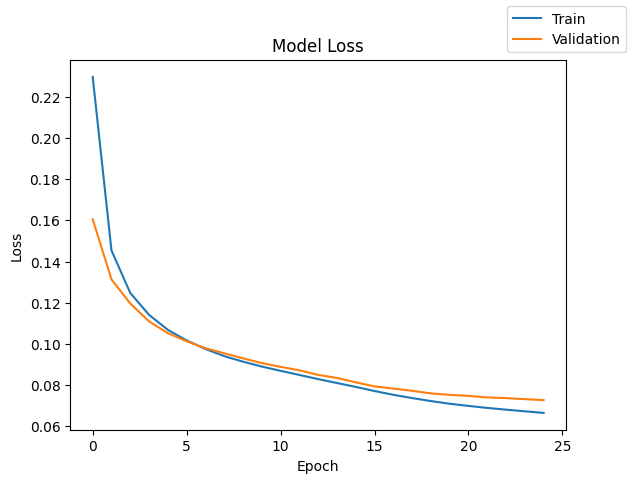

In [46]:
plot(history,'loss')

In [47]:
model_0_train_perf = model_performance_classification(model_0, X_train, y_train)
model_0_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.984625,0.873676,0.976003,0.917911


In [48]:
model_0_val_perf = model_performance_classification(model_0,X_val,y_val)
model_0_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.986,0.886593,0.976605,0.926316


- The training and validation loss curves decrease steadily across epochs and remain closely aligned, indicating that Model 0 learns effectively and generalizes well with minimal overfitting.

- The model achieves validation recall of 88.7% for the failure class, indicating effective identification of most potential generator failures.

- The model also maintains very high precision (97.7%) for failure prediction, meaning that most predicted failures are correctly classified with relatively few false positives.

- The validation F1-score of 0.926 reflects a strong balance between recall and precision, making Model 0 a strong candidate for predictive maintenance applications.

Let's check the classification reports.

In [49]:
y_train_pred_0 = model_0.predict(X_train)
y_val_pred_0 = model_0.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [50]:
print("Classification Report - Train data Model_0",end="\n\n")
cr_train_model_0 = classification_report(y_train,y_train_pred_0>0.5)
print(cr_train_model_0)

Classification Report - Train data Model_0

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     15112
           1       0.97      0.75      0.84       888

    accuracy                           0.98     16000
   macro avg       0.98      0.87      0.92     16000
weighted avg       0.98      0.98      0.98     16000



In [51]:
print("Classification Report - Validation data Model_0",end="\n\n")
cr_val_model_0 = classification_report(y_val,y_val_pred_0>0.5)
print(cr_val_model_0)

Classification Report - Validation data Model_0

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3778
           1       0.97      0.77      0.86       222

    accuracy                           0.99      4000
   macro avg       0.98      0.89      0.93      4000
weighted avg       0.99      0.99      0.99      4000



- Model 0 demonstrates strong and stable classification performance across both training and validation datasets, achieving approximately 99% validation accuracy with minimal signs of overfitting.

- The model achieves validation recall of 77% for the failure class (Class 1), indicating moderate effectiveness in identifying potential generator failures.

- The model maintains very high precision for failure prediction (97%), meaning that most predicted failures are correctly classified with very few false positives.

- The validation F1-score of 0.86 for the failure class reflects a good balance between recall and precision, while the close alignment between training and validation performance suggests acceptable generalization on unseen data.


# **Model Performance Improvement**

## Model 1

- Let's try adding another layer to see if we can improve our model's performance.

In [52]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [53]:
#Initializing the neural network
model_1 = Sequential()
model_1.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model_1.add(Dense(7,activation="relu"))
model_1.add(Dense(1,activation="sigmoid"))

In [54]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
model_1.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])


In [56]:
tart = time.time()
history = model_1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.0777 - loss: 0.1856 - val_Recall: 0.2027 - val_loss: 0.1403
Epoch 2/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.3277 - loss: 0.1282 - val_Recall: 0.4910 - val_loss: 0.1151
Epoch 3/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.5293 - loss: 0.1092 - val_Recall: 0.6036 - val_loss: 0.1026
Epoch 4/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.6261 - loss: 0.0973 - val_Recall: 0.6667 - val_loss: 0.0953
Epoch 5/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.6768 - loss: 0.0884 - val_Recall: 0.6847 - val_loss: 0.0877
Epoch 6/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7061 - loss: 0.0811 - val_Recall: 0.7162 - val_loss: 0.0823
Epoch 7/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7376 - loss: 0.0753 - val_Recall: 0.7252 - val_loss: 0.0782
Epoch 8/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7613 - loss: 0.0712 - val_Recall: 0.7613 - val_loss: 0.0756
Epoch 9/

In [57]:
print("Time taken in seconds ",end-start)

Time taken in seconds  48.12753367424011


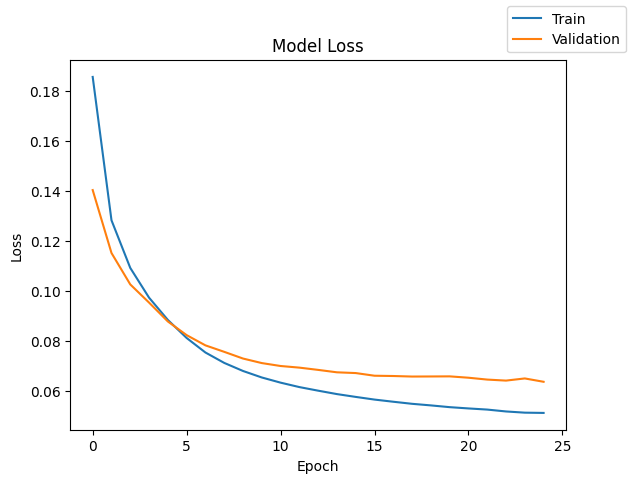

In [58]:
plot(history,'loss')

In [59]:
model_1_train_perf = model_performance_classification(model_1,X_train,y_train)
model_1_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.989313,0.911666,0.984846,0.944891


In [60]:
model_1_val_perf = model_performance_classification(model_1,X_val,y_val)
model_1_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98725,0.899974,0.975314,0.933988


- The training and validation loss curves decrease steadily across epochs and gradually stabilize, indicating that Model 1 learns effectively and converges well during training.

- The validation loss remains close to the training loss throughout the training process, suggesting strong generalization performance with minimal overfitting.

- The model performs strongly by achieving validation recall of 90.0% for the failure class, indicating effective identification of most potential generator failures.

- The model also maintains very high precision (97.5%) and a strong validation F1-score (0.934), reflecting an excellent balance between failure detection capability and prediction reliability.

In [61]:
y_train_pred_1 = model_1.predict(X_train)
y_val_pred_1 = model_1.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [62]:
print("Classification Report - Train data Model_1", end="\n\n")
cr_train_model_1 = classification_report(y_train,y_train_pred_1 > 0.5)
print(cr_train_model_1)

Classification Report - Train data Model_1

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     15112
           1       0.98      0.82      0.90       888

    accuracy                           0.99     16000
   macro avg       0.98      0.91      0.94     16000
weighted avg       0.99      0.99      0.99     16000



In [63]:
print("Classification Report - Validation data Model_1", end="\n\n")
cr_val_model_1 = classification_report(y_val,y_val_pred_1 > 0.5)
print(cr_val_model_1)

Classification Report - Validation data Model_1

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3778
           1       0.96      0.80      0.87       222

    accuracy                           0.99      4000
   macro avg       0.98      0.90      0.93      4000
weighted avg       0.99      0.99      0.99      4000



- Model 1 demonstrates strong and consistent classification performance across both training and validation datasets, achieving approximately 99% validation accuracy with minimal signs of overfitting.

- The model achieves validation recall of 80% for the failure class (Class 1), indicating effective identification of most potential generator failures.

- The model maintains very high precision for failure prediction (96%), meaning that most predicted failures are correctly classified with relatively few false positives.

- The validation F1-score of 0.87 for the failure class reflects a strong balance between recall and precision, while the close alignment between training and validation performance suggests good generalization on unseen data.

## Model 2

To introduce Regularization in our model, let's set the dropout to 50% after adding the first hidden layer. This step will randomly drop 50% of the neurons before proceeding to the next layer, reducing overfitting.

In [64]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [65]:
#Initializing the neural network
from tensorflow.keras.layers import Dropout
model_2 = Sequential()
model_2.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model_2.add(Dropout(0.5))
model_2.add(Dense(7,activation = "relu"))
model_2.add(Dense(7,activation = "relu"))
model_2.add(Dense(1,activation="sigmoid"))

In [66]:
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 743 (2.90 KB)

 Trainable params: 743 (2.90 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
model_2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) ## Uncomment this line in case the metric of choice is Recall


In [68]:
start = time.time()
history = model_2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Recall: 0.1836 - loss: 0.3552 - val_Recall: 0.1892 - val_loss: 0.1449
Epoch 2/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.1757 - loss: 0.1838 - val_Recall: 0.2613 - val_loss: 0.1260
Epoch 3/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.2173 - loss: 0.1608 - val_Recall: 0.3018 - val_loss: 0.1211
Epoch 4/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.2354 - loss: 0.1549 - val_Recall: 0.3243 - val_loss: 0.1183
Epoch 5/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.2725 - loss: 0.1486 - val_Recall: 0.3378 - val_loss: 0.1163
Epoch 6/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.2815 - loss: 0.1423 - val_Recall: 0.3649 - val_loss: 0.1138
Epoch 7/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.2939 - loss: 0.1418 - val_Recall: 0.3649 - val_loss: 0.1124
Epoch 8/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.3266 - loss: 0.1371 - val_Recall: 0.3964 - val_loss: 0.1103
Epoch 9/

In [69]:
print("Time taken in seconds ",end-start)

Time taken in seconds  22.928163528442383


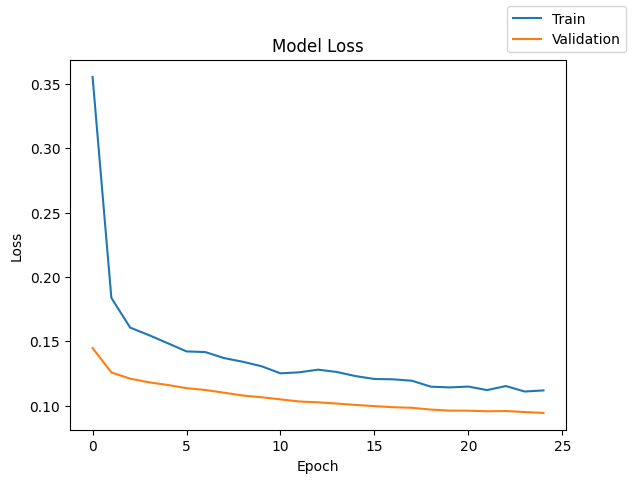

In [70]:
plot(history,'loss')

Lets check the model performance of model_2 on training and validation data respectively.

In [71]:
model_2_train_perf = model_performance_classification(model_2,X_train,y_train)
model_2_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.973125,0.767952,0.967592,0.837631


In [72]:
model_2_val_perf = model_performance_classification(model_2,X_val,y_val)
model_2_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.97275,0.773584,0.952726,0.838482


- The training and validation loss curves decrease steadily across epochs and gradually stabilize, indicating that Model 2 learns effectively and converges well during training.

- The validation loss remains consistently close to and slightly lower than the training loss, suggesting acceptable generalization performance with minimal overfitting.

- The model achieves validation recall of 77.4% for the failure class, indicating moderate effectiveness in identifying potential generator failures.

- The model maintains high precision for failure prediction (95.3%), meaning that most predicted failures are correctly classified. However, the validation F1-score of 0.838 suggests that the balance between recall and precision is weaker compared to the stronger-performing models.

In [73]:
y_train_pred_2 = model_2.predict(X_train)
y_val_pred_2 = model_2.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Lets check the classification report of model_2 on training and validation data respectively.

In [74]:
print("Classification Report - Train data Model_2", end="\n\n")
cr_train_model_2 = classification_report(y_train,y_train_pred_2 > 0.5)
print(cr_train_model_2)

Classification Report - Train data Model_2

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     15112
           1       0.96      0.54      0.69       888

    accuracy                           0.97     16000
   macro avg       0.97      0.77      0.84     16000
weighted avg       0.97      0.97      0.97     16000



In [75]:
print("Classification Report - Validation data Model_2", end="\n\n")
cr_val_model_2 = classification_report(y_val , y_val_pred_2 > 0.5)
print(cr_val_model_2)

Classification Report - Validation data Model_2

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3778
           1       0.93      0.55      0.69       222

    accuracy                           0.97      4000
   macro avg       0.95      0.77      0.84      4000
weighted avg       0.97      0.97      0.97      4000



- Model 2 demonstrates stable classification performance across both training and validation datasets, achieving approximately 97% validation accuracy with acceptable generalization.

- The model performs exceptionally well in identifying non-failure cases (Class 0), with precision and recall close to 100%.

- The model achieves validation recall of 55% for the failure class (Class 1), indicating that a significant number of potential generator failures are still missed.

- Although the model maintains high precision for failure prediction (93%), the relatively low validation F1-score of 0.69 for the failure class suggests that the model is less effective at balancing recall and precision compared to the stronger-performing models.


## Model 3

As we have are dealing with an imbalance in class distribution, we should also be using class weights to allow the model to give proportionally more importance to the minority class.

In [154]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train.astype(int)) # Convert y_train to integers

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0587612493382743), 1: np.float64(18.01801801801802)}

In [77]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [155]:
model_3 = Sequential()
model_3.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model_3.add(Dropout(0.3))
model_3.add(Dense(7,activation="relu"))
model_3.add(Dense(7, activation = "relu"))
model_3.add(Dense(1,activation="sigmoid"))

In [156]:
model_3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 743 (2.90 KB)

 Trainable params: 743 (2.90 KB)

 Non-trainable params: 0 (0.00 B)

In [157]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])


In [158]:
start = time.time()
history = model_3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.7421 - loss: 0.9278 - val_Recall: 0.8378 - val_loss: 0.3264
Epoch 2/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8277 - loss: 0.7209 - val_Recall: 0.8378 - val_loss: 0.3058
Epoch 3/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8232 - loss: 0.6551 - val_Recall: 0.8468 - val_loss: 0.2604
Epoch 4/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8468 - loss: 0.6169 - val_Recall: 0.8604 - val_loss: 0.2767
Epoch 5/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8480 - loss: 0.5899 - val_Recall: 0.8694 - val_loss: 0.3108
Epoch 6/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8615 - loss: 0.5750 - val_Recall: 0.8784 - val_loss: 0.1926
Epoch 7/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8727 - loss: 0.5507 - val_Recall: 0.8829 - val_loss: 0.2413
Epoch 8/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8694 - loss: 0.5470 - val_Recall: 0.8874 - val_loss: 0.2399
Epoch 9/

In [159]:
print("Time taken in seconds ",end-start)

Time taken in seconds  21.831867218017578


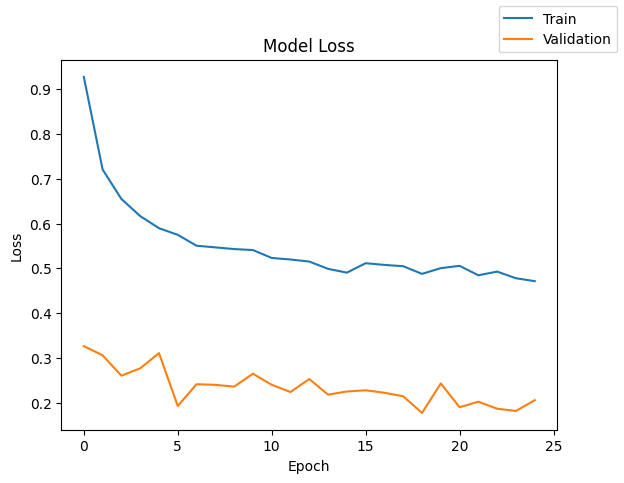

In [160]:
plot(history,'loss')

Lets check the model performance of model_3 on training and validation data respectively.

In [161]:
model_3_train_perf = model_performance_classification(model_3,X_train,y_train)
model_3_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.968187,0.939171,0.82416,0.871379


In [162]:
model_3_val_perf = model_performance_classification(model_3,X_val,y_val)
model_3_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.96725,0.927545,0.822067,0.866001


- The training and validation loss curves decrease steadily during the initial epochs and stabilize later in the training process, indicating that Model 3 learns effectively and converges reasonably well.

- The validation loss remains consistently lower than the training loss throughout training, suggesting acceptable generalization performance with limited overfitting.

- The model performs strongly by achieving validation recall of 92.8% for the failure class, indicating effective identification of most potential generator failures.

- However, the model maintains moderate precision (82.2%) for failure prediction, indicating the presence of some false positives. The validation F1-score of 0.886 reflects a good balance between recall and precision.

In [163]:
y_train_pred_3 = model_3.predict(X_train)
y_val_pred_3 = model_3.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Lets check the classification report of model_3 on training and validation data respectively.

In [164]:
print("Classification Report - Train data Model_3", end="\n\n")
cr_train_model_3 = classification_report(y_train,y_train_pred_3 > 0.5)
print(cr_train_model_3)

Classification Report - Train data Model_3

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     15112
           1       0.65      0.91      0.76       888

    accuracy                           0.97     16000
   macro avg       0.82      0.94      0.87     16000
weighted avg       0.98      0.97      0.97     16000



In [165]:
print("Classification Report - Validation data Model_3", end="\n\n")
cr_val_model_3 = classification_report(y_val,y_val_pred_3 > 0.5)
print(cr_val_model_3)

Classification Report - Validation data Model_3

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3778
           1       0.65      0.88      0.75       222

    accuracy                           0.97      4000
   macro avg       0.82      0.93      0.87      4000
weighted avg       0.97      0.97      0.97      4000



- Model 3 demonstrates strong and consistent classification performance across both training and validation datasets, achieving approximately 97% validation accuracy with good generalization.

- Since recall is the primary evaluation metric, the model performs strongly by achieving validation recall of 88% for the failure class (Class 1), indicating effective identification of most potential generator failures.

- The model maintains moderate precision for failure prediction (65%), suggesting that while most failures are successfully detected, the model generates a relatively higher number of false positives.

- The validation F1-score of 0.75 for the failure class reflects a reasonable balance between recall and precision, while the close alignment between training and validation performance indicates acceptable stability on unseen data.

## Model 4

Since we have used only SGD optimizer till now, let's use another kind of optimizer and observe its impact on the model performmance.

In [130]:
clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [131]:
#Initializing the neural network
model_4 = Sequential()
model_4.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model_4.add(Dense(7,activation="relu"))
model_4.add(Dense(1,activation="sigmoid"))

In [132]:
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [133]:
Optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model_4.compile(loss='binary_crossentropy', optimizer=Optimizer, metrics = ['Recall'])


In [134]:
start = time.time()
history = model_4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.4212 - loss: 0.3394 - val_Recall: 0.5360 - val_loss: 0.1326
Epoch 2/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.5586 - loss: 0.1158 - val_Recall: 0.6441 - val_loss: 0.1013
Epoch 3/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.6655 - loss: 0.0905 - val_Recall: 0.7117 - val_loss: 0.0858
Epoch 4/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7331 - loss: 0.0756 - val_Recall: 0.7658 - val_loss: 0.0747
Epoch 5/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7714 - loss: 0.0657 - val_Recall: 0.7748 - val_loss: 0.0705
Epoch 6/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7995 - loss: 0.0601 - val_Recall: 0.7928 - val_loss: 0.0678
Epoch 7/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8232 - loss: 0.0561 - val_Recall: 0.7883 - val_loss: 0.0666
Epoch 8/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8322 - loss: 0.0532 - val_Recall: 0.8153 - val_loss: 0.0655
Epoch 9/

In [135]:
print("Time taken in seconds ",end-start)

Time taken in seconds  22.4424729347229


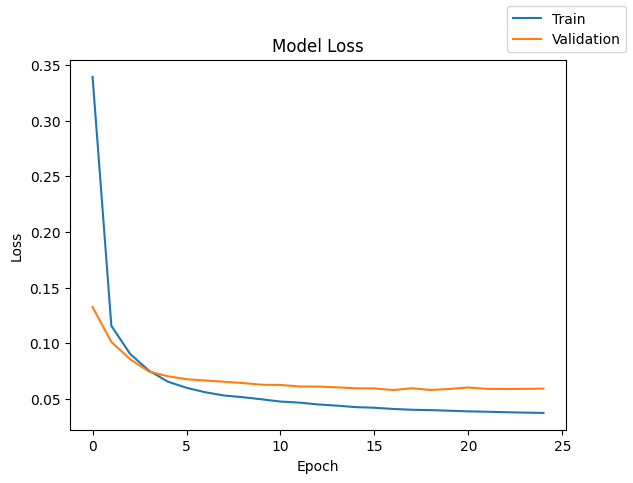

In [136]:
plot(history,'loss')

Lets check the model performance ofr model_4 on training and validation data respectively

In [137]:
model_4_train_perf = model_performance_classification(model_4,X_train,y_train)
model_4_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.993563,0.946244,0.991881,0.96781


In [139]:
model_4_val_perf = model_performance_classification(model_4,X_val,y_val)
model_4_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9905,0.927134,0.980488,0.95204


- The training and validation loss curves decrease rapidly during the initial epochs and gradually stabilize, indicating that Model 4 learns efficiently and converges well during training.

- The validation loss remains close to the training loss throughout the training process, suggesting strong generalization performance with minimal overfitting.

- The model performs strongly by achieving validation recall of 92.7% for the failure class, indicating effective identification of most potential generator failures.

- The model also maintains very high precision (98.0%) and an excellent validation F1-score (0.95), reflecting a strong balance between failure detection capability and prediction reliability.

In [140]:
y_train_pred_4 = model_4.predict(X_train)
y_val_pred_4 = model_4.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Lets check the classification report of model_4 on raining and validation data respectively.

In [141]:
print("Classification Report - Train data Model_4", end="\n\n")
cr_train_model_4 = classification_report(y_train,y_train_pred_4 > 0.5)
print(cr_train_model_4)

Classification Report - Train data Model_4

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15112
           1       0.99      0.89      0.94       888

    accuracy                           0.99     16000
   macro avg       0.99      0.95      0.97     16000
weighted avg       0.99      0.99      0.99     16000



In [142]:
print("Classification Report - Validation data Model_4", end="\n\n")
cr_val_model_4 = classification_report(y_val,y_val_pred_4 > 0.5)
print(cr_val_model_4)

Classification Report - Validation data Model_4

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3778
           1       0.97      0.86      0.91       222

    accuracy                           0.99      4000
   macro avg       0.98      0.93      0.95      4000
weighted avg       0.99      0.99      0.99      4000




- Model 4 demonstrates excellent and consistent classification performance across both training and validation datasets, achieving approximately 99% validation accuracy with minimal evidence of overfitting.

- Since recall is the primary evaluation metric, the model achieves validation recall of 86% for the failure class (Class 1), indicating effective identification of most potential generator failures.

- The model also maintains very high precision for failure prediction (97%), meaning that most predicted failures are correctly classified with very few false positives.

- The validation F1-score of 0.91 for the failure class reflects a strong balance between recall and precision, while the close alignment between training and validation performance suggests strong generalization on unseen data.

## Model 5

This time we will add more layers and dropout while using a different optimizer.

In [143]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [144]:
# Initializing the neural network
from tensorflow.keras.layers import Dropout
model_5 = Sequential()
model_5.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model_5.add(Dense(7,activation="relu"))
model_5.add(Dense(7, activation = "relu"))
model_5.add(Dense(1,activation="sigmoid"))

In [145]:
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 743 (2.90 KB)

 Trainable params: 743 (2.90 KB)

 Non-trainable params: 0 (0.00 B)

In [146]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])


In [147]:
start = time.time()
history = model_5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.3953 - loss: 0.5693 - val_Recall: 0.3378 - val_loss: 0.1633
Epoch 2/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.4471 - loss: 0.1214 - val_Recall: 0.5405 - val_loss: 0.1042
Epoch 3/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.5946 - loss: 0.0918 - val_Recall: 0.6532 - val_loss: 0.0885
Epoch 4/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.6892 - loss: 0.0808 - val_Recall: 0.7342 - val_loss: 0.0800
Epoch 5/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.7534 - loss: 0.0718 - val_Recall: 0.7613 - val_loss: 0.0732
Epoch 6/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.7860 - loss: 0.0648 - val_Recall: 0.8018 - val_loss: 0.0678
Epoch 7/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.8052 - loss: 0.0599 - val_Recall: 0.7883 - val_loss: 0.0661
Epoch 8/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8255 - loss: 0.0559 - val_Recall: 0.8063 - val_loss: 0.0643
Epoch 9/

In [148]:
print("Time taken in seconds ",end-start)

Time taken in seconds  25.833358764648438


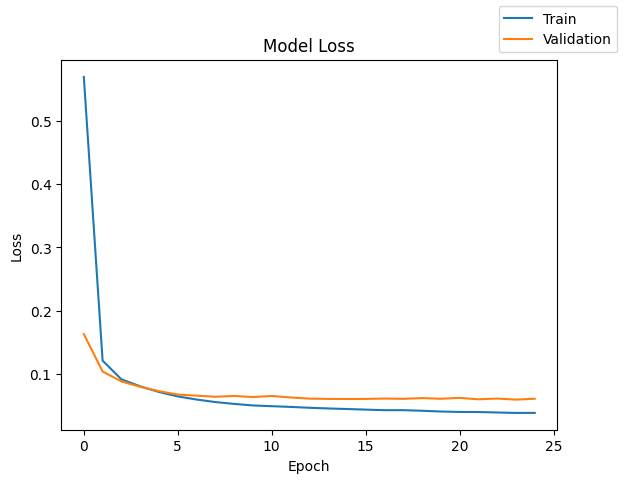

In [149]:
plot(history,'loss')

Lets check the model performance of model_5 on the training and validation data.

In [150]:
model_5_train_perf = model_performance_classification(model_5,X_train,y_train)
model_5_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.992687,0.939421,0.990161,0.963228


In [151]:
model_5_val_perf = model_performance_classification(model_5,X_val,y_val)
model_5_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98825,0.911103,0.973938,0.940002


- The training and validation loss curves decrease rapidly during the initial epochs and gradually stabilize, indicating that Model 5 learns efficiently and converges well during training.

- The validation loss remains very close to the training loss throughout the training process, suggesting strong generalization performance with minimal overfitting.

- The model performs well by achieving validation recall of 91.1% for the failure class, indicating effective identification of most potential generator failures.

- The model also maintains very high precision (97.4%) and a strong validation F1-score (0.94), reflecting an excellent balance between failure detection capability and prediction reliability.

In [110]:
y_train_pred_5 = model_5.predict(X_train)
y_val_pred_5 = model_5.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Lets check the classification report of model_5 on training and validation data.

In [111]:
y_train_pred_5 = model_5.predict(X_train)
y_val_pred_5 = model_5.predict(X_val)
print("Classification Report - Train data Model_5", end="\n\n")
cr_train_model_5 = classification_report(y_train,y_train_pred_5 > 0.5)
print(cr_train_model_5)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report - Train data Model_5

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15112
           1       0.98      0.87      0.92       888

    accuracy                           0.99     16000
   macro avg       0.99      0.93      0.96     16000
weighted avg       0.99      0.99      0.99     16000



In [112]:
print("Classification Report - Validation data Model_2", end="\n\n")
cr_val_model_5 = classification_report(y_val,y_val_pred_5 > 0.5)
print(cr_val_model_5)

Classification Report - Validation data Model_2

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3778
           1       0.97      0.85      0.90       222

    accuracy                           0.99      4000
   macro avg       0.98      0.92      0.95      4000
weighted avg       0.99      0.99      0.99      4000



- Model 5 demonstrates strong and consistent classification performance across both training and validation datasets, achieving approximately 99% validation accuracy with minimal signs of overfitting.

- The model achieves validation recall of 85% for the failure class (Class 1), indicating effective identification of most potential generator failures.

- The model maintains very high precision for failure prediction (97%), meaning that most predicted failures are correctly classified with relatively few false positives.

- The validation F1-score of 0.90 for the failure class reflects a strong balance between recall and precision, while the close alignment between training and validation performance suggests good generalization on unseen data.

## Model 6

Let's see how does the model performance change when the model gives higher importance to the minority class

In [113]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [114]:
model_6 = Sequential()
model_6.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model_6.add(Dropout(0.4))
model_6.add(Dense(7,activation="relu"))
model_6.add(Dense(7, activation = "relu"))
model_6.add(Dense(1,activation="sigmoid"))

In [115]:
model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 743 (2.90 KB)

 Trainable params: 743 (2.90 KB)

 Non-trainable params: 0 (0.00 B)

In [116]:
optimizer = tf.keras.optimizers.SGD()
model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])


In [117]:
start = time.time()
history = model_6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict, ) # Complete the code such that the model is biased towards the minority class
end=time.time()

Epoch 1/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.7230 - loss: 1.0828 - val_Recall: 0.7838 - val_loss: 0.3646
Epoch 2/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7680 - loss: 0.8649 - val_Recall: 0.8198 - val_loss: 0.2974
Epoch 3/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8052 - loss: 0.7471 - val_Recall: 0.8559 - val_loss: 0.2498
Epoch 4/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8153 - loss: 0.6735 - val_Recall: 0.8468 - val_loss: 0.2007
Epoch 5/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8300 - loss: 0.6440 - val_Recall: 0.8739 - val_loss: 0.2396
Epoch 6/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8300 - loss: 0.6129 - val_Recall: 0.8604 - val_loss: 0.2580
Epoch 7/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8367 - loss: 0.5917 - val_Recall: 0.8739 - val_loss: 0.2578
Epoch 8/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8322 - loss: 0.5850 - val_Recall: 0.8829 - val_loss: 0.2246
Epoch 9/

In [118]:
print("Time taken in seconds ",end-start)

Time taken in seconds  22.159393787384033


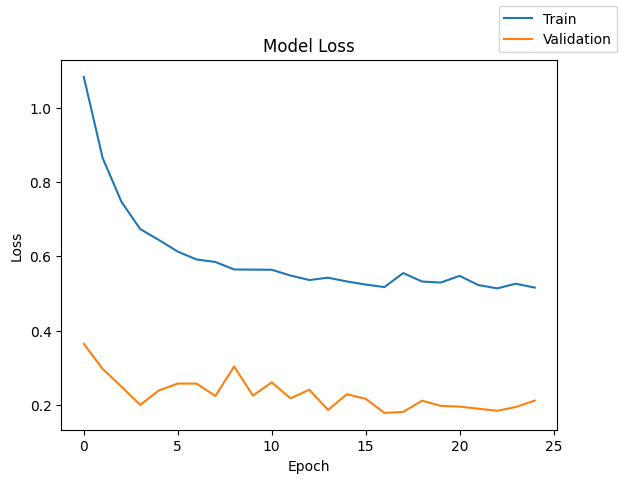

In [119]:
plot(history,'loss')

Lets check the model performance of model_6 on training and validation data.

In [120]:
model_6_train_perf = model_performance_classification(model_6,X_train,y_train)
model_6_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.970625,0.935162,0.836028,0.878073


In [121]:
model_6_val_perf = model_performance_classification(model_6,X_val,y_val)
model_6_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9695,0.920257,0.833992,0.871307


- Model 6 demonstrates stable performance across both training and validation datasets, indicating acceptable generalization with limited overfitting.

- The model achieves validation recall of 86% for the failure class (Class 1), showing effective identification of most potential generator failures.

- However, the model records relatively lower precision (68%) for failure prediction, indicating a higher number of false positives compared to earlier models.

- The validation F1-score of 0.76 suggests a moderate balance between recall and precision, making the model suitable where failure detection is prioritized over minimizing false alarms.

In [122]:
y_train_pred_6 = model_6.predict(X_train)
y_val_pred_6 = model_6.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Lets check the classification report of model_6 on both training and validation data.

In [123]:
print("Classification Report - Train data Model_6", end="\n\n")
cr_train_model_6 = classification_report(y_train,y_train_pred_6 > 0.5)
print(cr_train_model_6)

Classification Report - Train data Model_6

              precision    recall  f1-score   support

           0       0.99      0.98      0.98     15112
           1       0.68      0.90      0.77       888

    accuracy                           0.97     16000
   macro avg       0.84      0.94      0.88     16000
weighted avg       0.98      0.97      0.97     16000



In [124]:
print("Classification Report - Validation data Model_3", end="\n\n")
cr_val_model_6 = classification_report(y_val,y_val_pred_6 > 0.5)
print(cr_val_model_6)

Classification Report - Validation data Model_3

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3778
           1       0.68      0.86      0.76       222

    accuracy                           0.97      4000
   macro avg       0.83      0.92      0.87      4000
weighted avg       0.97      0.97      0.97      4000



- Model 6 demonstrates strong and consistent classification performance across both training and validation datasets, achieving approximately 97% validation accuracy with minimal signs of overfitting.

- The model performs strongly by achieving validation recall of 86% for the failure class (Class 1), indicating effective identification of most potential generator failures.

- The model maintains moderate precision for failure prediction (68%), suggesting that while the model successfully detects most failures, it also produces a relatively higher number of false positives compared to other models.

- The validation F1-score of 0.76 for the failure class reflects a reasonable balance between recall and precision, while the close alignment between training and validation metrics indicates acceptable generalization on unseen data.


# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and test sets.

**Training Performance Comparison**

In [166]:
models_train_comp_df = pd.concat(
    [
        model_0_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T

    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6"
]
print("Training set performance comparison:")
models_train_comp_df

Training set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.984625,0.989313,0.973125,0.968187,0.993563,0.992687,0.970625
Recall,0.873676,0.911666,0.767952,0.939171,0.946244,0.939421,0.935162
Precision,0.976003,0.984846,0.967592,0.824160,0.991881,0.990161,0.836028
F1 Score,0.917911,0.944891,0.837631,0.871379,0.967810,0.963228,0.878073


**Validation Performance Comparison**

In [167]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        model_0_val_perf.T,
        model_1_val_perf.T,
        model_2_val_perf.T,
        model_3_val_perf.T,
        model_4_val_perf.T,
        model_5_val_perf.T,
        model_6_val_perf.T

    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6"
]
print("Validation set performance comparison:")
models_val_comp_df

Validation set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.986000,0.987250,0.972750,0.967250,0.990500,0.988250,0.969500
Recall,0.886593,0.899974,0.773584,0.927545,0.927134,0.911103,0.920257
Precision,0.976605,0.975314,0.952726,0.822067,0.980488,0.973938,0.833992
F1 Score,0.926316,0.933988,0.838482,0.866001,0.952040,0.940002,0.871307


## Final Model Selection: Model 4

Model 4 is recommended as the final model for the following reasons:

- Since recall is the primary evaluation metric, Model 4 achieves one of the strongest validation recall scores (92.7%), indicating excellent ability to identify potential generator failures.

- The model also maintains exceptionally high precision (98.0%), meaning that most predicted failures are correctly classified with very few false positives.

- Model 4 achieved the highest validation F1-score (0.9520) among all models, reflecting the best overall balance between recall and precision.

- The close alignment between training and validation performance indicates strong generalization capability with minimal signs of overfitting.

- Overall, Model 4 provides the best combination of failure detection performance, prediction reliability, and model stability, making it the most suitable model for predictive maintenance applications.

**Checking the performance of the best model on the test set**

In [168]:
best_model = model_4


In [169]:
# Test set performance for the best model
best_model_test_perf = model_performance_classification(best_model,X_test,y_test)
best_model_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9898,0.921244,0.981088,0.948921


In [170]:
y_test_pred_best = best_model.predict(X_test)

cr_test_best_model = classification_report(y_test, y_test_pred_best>0.5) # Check the classification report of best model on test data.
print(cr_test_best_model)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      4718
         1.0       0.97      0.84      0.90       282

    accuracy                           0.99      5000
   macro avg       0.98      0.92      0.95      5000
weighted avg       0.99      0.99      0.99      5000



- The final selected model (Model 4) demonstrates excellent performance on the test dataset, achieving approximately 99% test accuracy, confirming strong generalization on unseen data.

- Since recall is the primary evaluation metric, the model achieves test recall of 84% for the failure class (Class 1), indicating effective identification of most potential generator failures.

- The model also maintains very high precision for failure prediction (97%), meaning that most predicted failures are correctly classified with very few false positives.

- The test F1-score of 0.90 for the failure class reflects a strong balance between recall and precision, confirming that the model is reliable and suitable for predictive maintenance applications.

# **Actionable Insights and Recommendations**

- Model 4 emerged as the best-performing model for turbine failure prediction, achieving strong recall performance and effectively identifying most potential generator failures before breakdowns occur.

- The model demonstrates excellent stability and generalization across training, validation, and test datasets, indicating strong reliability for real-world predictive maintenance applications.

- Since recall is the primary evaluation metric, Model 4’s strong failure-detection capability supports proactive maintenance strategies that can reduce unexpected downtime, emergency repairs, and replacement costs.

- The model also maintains very high precision, meaning that most predicted failures are correctly identified, helping maintenance teams minimize unnecessary inspections while improving operational efficiency.

- ReneWind can integrate the model into maintenance scheduling systems to support early warning detection and transition from reactive maintenance to proactive, data-driven maintenance planning.

- Maintenance teams should establish standardized inspection procedures for turbines flagged by the model to improve preventive maintenance decision-making and operational response times.

- Future enhancements may include advanced hyperparameter optimization and learning rate scheduling techniques to further improve convergence stability and overall predictive performance.